# 44 — does the molecule-level QM block carry information worth having?

`scripts/run_qm_descriptors.py` finished on 2026-10-05: 5,655 compounds, 11,310 ORCA jobs,
281.6 core-hours, zero failures. This notebook answers the molecule-level question about it —
**does the QM block carry information that improves pIC50 prediction over what this repo already
computes for free, and if so does it belong as features in a single model or as a decorrelated
ensemble member?**

Report only. All training was done by `scripts/44_run_qm_arms.py`; all feature construction and
the pre-registration by `scripts/44_build_qm_feature_blocks.py`; the label-free characterisation
by `scripts/44_redundancy_triage.py`. Nothing is trained here, no submission artefact is built,
and notebooks `32` and `40` (which carry live submission code) are never opened.

**This is not a submission decision.** Four CV-to-board transfer failures are on record, and the
diagnostic that did predict board movement — prediction-spread compression of a submitted
column — is a property of a column, not of CV, and this design cannot produce it. `prereg.json`
says so, frozen before any training run.

**Read `prereg.json` first.** Every criterion, bar, control-column list and the display subset
were frozen before a single arm ran.

> ### Limitation a reader must weigh: `prereg.json` was rewritten after training
>
> `prereg.json` carries mtime **2026-10-07 23:18:30**. That post-dates **459 of 476** prediction
> files, **228 of 228** tier-1 files and **44 of 44** feature CSVs, and the file was never committed,
> so **no git history exists for it**. The cause is recorded as decision **D4**: the feature builder
> was re-run after training in order to add an assertion, and re-running the builder rewrites the
> file it writes.
>
> So the *freeze artefact* is broken. Every claim below of the form "frozen before any arm ran" rests
> on the file's own `written_at_utc` field, which is self-reported, plus a content comparison made
> within the authoring session. Neither is independent evidence.
>
> Two things limit the damage, and both are independently checkable by anyone with the repo:
>
> * **The materiality bars cannot encode the outcome.** They reproduce to the digit as 2x each
>   isoform's mean paired ST-RAE SE from `outputs/37_butina_5x5_complete/paired_tests_vs_plain_25fold.csv`,
>   whose mtime is **2026-10-02**, five days before this experiment. A file that old cannot have been
>   fitted to results that did not exist.
> * **The training data is unchanged.** Refitting four arm/fold cells from the current feature CSVs
>   reproduces predictions written before the rewrite to **8.882e-16**, machine epsilon for a CSV
>   round-trip. Every arm was trained on exactly these bytes.
>
> What is *not* recoverable is the provenance of the **criteria text itself** - the wording of I.1
> to I.6, criterion II and the pre-declared negative. Those are the parts a pre-registration exists
> to protect, and for them the only evidence is session-internal. A reader who wants the criteria
> independently attested will not find it here. `prereg.json` is committed from this point on so the
> problem cannot recur.

In [1]:
import os

# OMP_NUM_THREADS is ASSERTED unset: notebook 34 established that restricting BLAS/OMP to one
# thread changes floating-point reduction order and so chemprop's training trajectory, breaking
# bit-reproducibility against notebook 05's stored scores.
# KMP_DUPLICATE_LIB_OK is only REPORTED: notebook 40's Part 8 established `import xgboost` SETS
# it, so an assertion placed after imports is unsatisfiable -- the exact defect that broke
# notebook 40 on a top-to-bottom re-run.
assert "OMP_NUM_THREADS" not in os.environ, "OMP_NUM_THREADS is set -- unset it and restart."
_KMP_AT_START = os.environ.get("KMP_DUPLICATE_LIB_OK")

import hashlib, importlib.metadata, json, subprocess, sys, warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import scikit_posthocs as sp
from scipy import stats
from scipy.stats import levene, ttest_rel
from statsmodels.stats.multitest import multipletests

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
from src.vendor.openadmet_eval.config import ACTIVITY_METRICS, REGRESSION_ENDPOINTS

METRIC_NAMES = [n for n, _ in ACTIVITY_METRICS]
ISOFORMS = [e.split("_")[0] for e in REGRESSION_ENDPOINTS]
EP_TO_ISO = {f"{i}_pIC50_direct_inhibition": i for i in ISOFORMS}
PIC50_COL = {i: f"{i}_pIC50_direct_inhibition" for i in ISOFORMS}

OUT = REPO_ROOT / "outputs" / "44_qm_molecular_block"
FIG = OUT / "figures"; FIG.mkdir(parents=True, exist_ok=True)
NB37 = REPO_ROOT / "outputs" / "37_butina_5x5_complete"
CURATED = REPO_ROOT / "data" / "processed" / "train_inhibition_curated.csv"

RUN_STARTED_AT = datetime.now(timezone.utc)
# Record which tracked paths are ALREADY dirty, so the scope check at the end asks "did THIS run
# dirty it" rather than "is it dirty" -- notebook 42's fix for the third recurrence of that bug.
_dirty = [l[3:].strip() for l in subprocess.run(
    ["git", "status", "--porcelain"], cwd=REPO_ROOT, capture_output=True, text=True
).stdout.splitlines() if l[:2].strip() and not l.startswith("??")]
(OUT / "run_meta.json").write_text(json.dumps(
    {"notebook": "44_qm_molecular_block", "started_at_utc": RUN_STARTED_AT.isoformat(),
     "started_at_epoch": RUN_STARTED_AT.timestamp(), "dirty_at_start": _dirty}, indent=2))
print(f"tracked paths already dirty before this run: {_dirty if _dirty else 'none'}")

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"python {sys.version.split()[0]}")
for p in ["numpy", "pandas", "scipy", "scikit-learn", "rdkit", "chemprop", "torch",
          "lightgbm", "xgboost", "pingouin", "scikit-posthocs", "statsmodels"]:
    try: print(f"  {p}: {importlib.metadata.version(p)}")
    except importlib.metadata.PackageNotFoundError: pass
print(f"\nKMP_DUPLICATE_LIB_OK at kernel start: {_KMP_AT_START!r} (reported, never asserted)")
print(f"KMP_DUPLICATE_LIB_OK now:             {os.environ.get('KMP_DUPLICATE_LIB_OK')!r}")

tracked paths already dirty before this run: none
python 3.11.13
  numpy: 1.26.4
  pandas: 2.3.3
  scipy: 1.17.1
  scikit-learn: 1.9.0
  rdkit: 2026.3.3
  chemprop: 2.3.1
  torch: 2.13.0
  lightgbm: 4.7.0
  xgboost: 3.2.0
  pingouin: 0.6.1
  scikit-posthocs: 0.14.0
  statsmodels: 0.14.6

KMP_DUPLICATE_LIB_OK at kernel start: None (reported, never asserted)
KMP_DUPLICATE_LIB_OK now:             'True'


## Part 0 — the pre-registration, and what it fixed before anything ran

`prereg.json` was written by the feature builder, before `44_run_qm_arms.py` was invoked for the
first time. It is echoed here rather than paraphrased.

In [2]:
PRE = json.loads((OUT / "prereg.json").read_text())
print(f"prereg.json frozen {PRE['written_at_utc']}  by {PRE['written_by']}")
print(f"sha256 {hashlib.sha256((OUT / 'prereg.json').read_bytes()).hexdigest()}")

BARS = PRE["resolution"]["materiality_bar_2se"]
SE37 = PRE["resolution"]["paired_se_nb37"]
print(f"\nmateriality bar = 2 x that isoform's own mean paired ST-RAE SE, measured across")
print(f"notebook 37's 10 arms x 25 folds -- NOT an invented number:")
for i in ISOFORMS:
    print(f"  {i}  SE {SE37[i]:.4f}  ->  bar {BARS[i]:.3f}")

print("\nfrozen control-column lists (chosen on chemistry, before any result existed):")
for k in ["RDKIT_MATCH18", "RDKIT_MATCH3_ELEC", "RDKIT_MATCH3_NEW3"]:
    print(f"  {k}: {PRE['blocks'][k]['columns']}")
print(f"\nfrozen display subset ({len(PRE['frozen_display_subset']['arms'])} arms): "
      f"{PRE['frozen_display_subset']['arms']}")
DISPLAY_SUBSET = PRE["frozen_display_subset"]["arms"]

print("\nzero-variance columns found in the free block (not assumed):")
zv = PRE["rdkit2d_zero_variance_columns"]
print(f"  {zv['n_zero_variance']} of {zv['n_descriptor_columns']} are identically 0, leaving "
      f"{zv['n_informative']} informative")
print(f"  {zv['columns']}")

M_STAR = json.loads((OUT / "model_selection.json").read_text())["m_star"]
print(f"\nM* = {M_STAR}  (selected on the CONTROL block at tier-1, before any QM arm was read)")

prereg.json frozen 2026-10-07T22:18:30.647720+00:00  by scripts/44_build_qm_feature_blocks.py
sha256 dbacd97aa28698b2ea56da2a8fbaf02cec557c2ad76103d27b76213b93f447e5

materiality bar = 2 x that isoform's own mean paired ST-RAE SE, measured across
notebook 37's 10 arms x 25 folds -- NOT an invented number:
  CYP1A2  SE 0.0117  ->  bar 0.023
  CYP2C9  SE 0.0104  ->  bar 0.021
  CYP2D6  SE 0.0138  ->  bar 0.028
  CYP3A4  SE 0.0080  ->  bar 0.016

frozen control-column lists (chosen on chemistry, before any result existed):
  RDKIT_MATCH18: ['MaxPartialCharge', 'MinPartialCharge', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'MaxEStateIndex', 'MinEStateIndex', 'TPSA', 'FractionCSP3', 'NumAromaticRings', 'MolMR', 'LabuteASA', 'NumRotatableBonds', 'BertzCT', 'Chi1n', 'Kappa2', 'Kappa3', 'HallKierAlpha', 'PEOE_VSA6']
  RDKIT_MATCH3_ELEC: ['fr_aniline', 'FractionCSP3', 'NumAromaticRings']
  RDKIT_MATCH3_NEW3: ['NumHeteroatoms', 'BalabanJ', 'PEOE_VSA8']

frozen display subset (9 arms): ['plain', 'deadzone',

### The sanity gate

The pipeline reproduces notebook 05's own stored `chemprop_chemeleoninit` `repeat0_fold0` scores
before anything else is believed. This is the tenth consecutive piece of work in this project to
pass that check (18/20/22/28/29/31/34/35/37).

In [3]:
sv = json.loads((OUT / "sanity_verdict.json").read_text())
sc = pd.read_csv(OUT / "sanity_check.csv")
print(sc.to_string(index=False, float_format=lambda v: f"{v:.10f}"))
print(f"\nmax abs ST-RAE difference {sv['max_abs_strae_diff']:.10f}  threshold {sv['threshold']}")
assert sv["pass"], "sanity gate did not pass -- nothing below is interpretable"
print("PASS -- bit-identical on all four isoforms.")

                      Endpoint     this_run         nb05     abs_diff
CYP1A2_pIC50_direct_inhibition 0.7883875413 0.7883875413 0.0000000000
CYP2C9_pIC50_direct_inhibition 0.7113010721 0.7113010721 0.0000000000
CYP2D6_pIC50_direct_inhibition 0.9580366078 0.9580366078 0.0000000000
CYP3A4_pIC50_direct_inhibition 0.4910353466 0.4910353466 0.0000000000

max abs ST-RAE difference 0.0000000000  threshold 0.03
PASS -- bit-identical on all four isoforms.


## Part 1 — what the QM columns are, before any model sees a label

`scripts/44_redundancy_triage.py` measures every candidate column two ways, with no label
touched: against molecular size, and against the free 2D block
(`tabular_baseline_features_rdkit2d.csv`'s 217 descriptors plus `ecfp4_narrow`'s 9
non-fingerprint columns = 226 predictors).

Three recoverability measures are reported because they disagree, and the disagreements matter.
The headline figure is the **max** of the linear and nonlinear readings — if any cheap model
reproduces a column, it is cheaply reproducible.

**This table ranks columns by how much of each is already cheaply measurable. It does not
establish that any column is redundant for prediction.** R² 0.65 leaves 35% of the variance
unexplained, and the increment arms in Part 4 are built to use exactly that residual. Two
reasons to read every figure as an *upper bound* on cheap reproduction: the reported value is
the max of two estimates, which is upward-biased by construction; and a column reproduced at
R² 0.90 can still carry the only usable signal in a block if that signal lives in the residual.

In [4]:
tri = pd.read_csv(OUT / "redundancy_triage.csv")
show = ["column", "group", "max_abs_size_corr", "max_abs_rho_single_free",
        "cv_R2_rank_ridge_free", "cv_R2_histgb_free", "cv_R2_max_free",
        "cv_R2_rank_ridge_mordred_pca"]
for grp, label in [("b_size_proxy", "(b) SIZE / COMPOSITION PROXIES"),
                   ("c_reproducible", "(c) REPRODUCIBLE FROM THE FREE 2D BLOCK"),
                   ("a_genuine", "(a) GENUINE -- not cheaply reproducible"),
                   ("reparameterisation", "REPARAMETERISATIONS (excluded from every block)")]:
    g = tri[tri.group == grp].sort_values("cv_R2_max_free", ascending=False)
    print(f"\n{label}  ({len(g)} columns)")
    print(g[show[2:]].set_index(g["column"]).round(4).to_string())

print("\n" + "=" * 78)
gen = tri[tri.group == "a_genuine"]
irr = gen.nsmallest(3, "cv_R2_max_free")
print(f"The three least cheaply-reproducible quantities in the whole run:")
for r in irr.itertuples():
    print(f"  {r.column:22s} max cheap R^2 {r.cv_R2_max_free:.4f}   "
          f"size |corr| {r.max_abs_size_corr:.3f}")
print(f"\nFor the frontier orbitals a cheap model reproduces "
      f"{gen[gen.column.str.contains('homo|lumo|gap')].cv_R2_max_free.min():.2f}-"
      f"{gen[gen.column.str.contains('homo|lumo|gap')].cv_R2_max_free.max():.2f}; for the "
      f"Hirshfeld summaries "
      f"{tri[tri.column.str.startswith('hirshfeld')].cv_R2_max_free.min():.3f}-"
      f"{tri[tri.column.str.startswith('hirshfeld')].cv_R2_max_free.max():.3f}.")


(b) SIZE / COMPOSITION PROXIES  (5 columns)
                    max_abs_size_corr  max_abs_rho_single_free  cv_R2_rank_ridge_free  cv_R2_histgb_free  cv_R2_max_free  cv_R2_rank_ridge_mordred_pca
column                                                                                                                                                
heavy_atoms                    1.0000                   1.0000                 1.0000             0.9862          1.0000                        0.9910
n_basis                        0.9873                   0.9844                 0.9989             0.9835          0.9989                        0.9929
gfn2_energy_eh                 0.9651                   0.9898                 0.9987             0.9835          0.9987                        0.9738
total_atoms_with_h             0.8133                   0.9413                 0.9912             0.9741          0.9912                        0.9341
dft_dispersion_eh              0.8583            

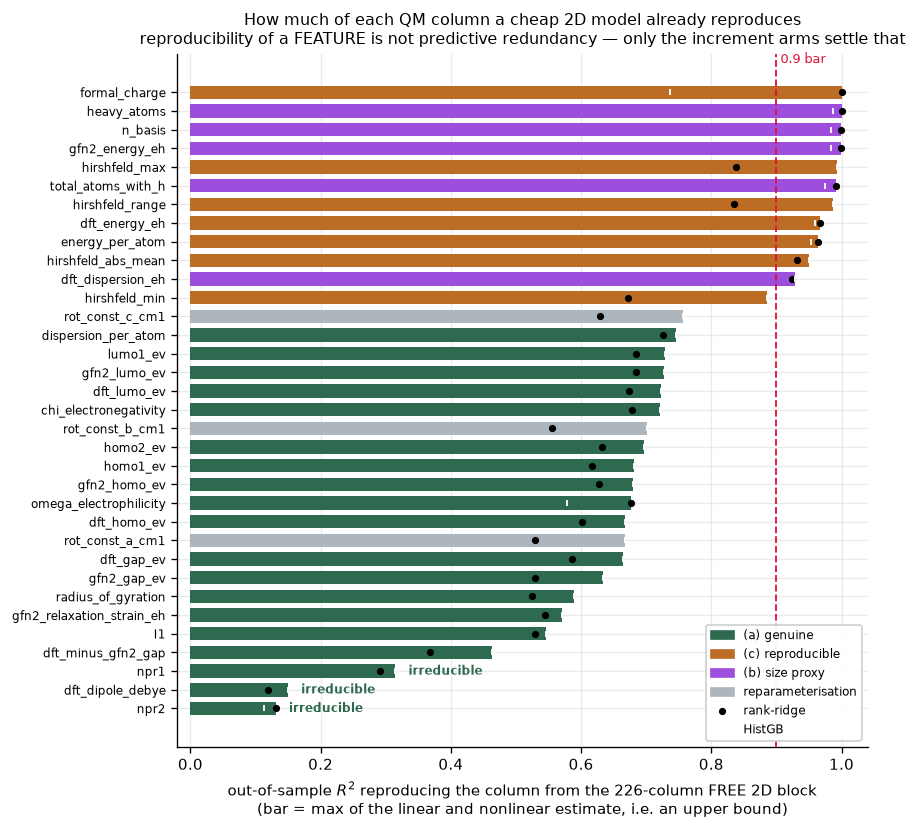

In [5]:
# FIGURE 1 -- the plan's headline, and the figure most likely to reach a discussion chapter.
fig, ax = plt.subplots(figsize=(7.4, 7.0))
d = tri.sort_values("cv_R2_max_free")
colour = {"a_genuine": "#2d6a4f", "c_reproducible": "#bc6c25",
          "b_size_proxy": "#9d4edd", "reparameterisation": "#adb5bd"}
y = np.arange(len(d))
ax.barh(y, d.cv_R2_max_free, color=[colour[g] for g in d.group], height=0.72, zorder=3)
ax.scatter(d.cv_R2_rank_ridge_free, y, s=11, color="k", zorder=5, label="rank-ridge (linear)")
ax.scatter(d.cv_R2_histgb_free, y, s=11, marker="|", color="w", zorder=6,
           linewidths=1.1, label="HistGB (nonlinear)")
ax.set_yticks(y); ax.set_yticklabels(d.column, fontsize=7.4)
ax.axvline(0.9, color="crimson", ls="--", lw=1.1, zorder=4)
ax.text(0.9, len(d) + 0.4, " 0.9 bar", color="crimson", fontsize=7.5, va="bottom")
ax.set_xlabel("out-of-sample $R^2$ reproducing the column from the 226-column FREE 2D block\n"
              "(bar = max of the linear and nonlinear estimate, i.e. an upper bound)")
ax.set_xlim(-0.02, 1.04)
for r, yy in zip(d.itertuples(), y):
    if r.column in set(irr.column):
        ax.annotate("irreducible", (r.cv_R2_max_free + 0.02, yy), fontsize=7,
                    color="#2d6a4f", va="center", fontweight="bold")
h = [plt.Rectangle((0, 0), 1, 1, color=colour[k]) for k in
     ["a_genuine", "c_reproducible", "b_size_proxy", "reparameterisation"]]
ax.legend(h + list(ax.get_legend_handles_labels()[0]),
          ["(a) genuine", "(c) reproducible", "(b) size proxy", "reparameterisation",
           "rank-ridge", "HistGB"], fontsize=7, loc="lower right", framealpha=0.95)
ax.set_title("How much of each QM column a cheap 2D model already reproduces\n"
             "reproducibility of a FEATURE is not predictive redundancy — only the increment "
             "arms settle that", fontsize=9.5)
fig.tight_layout(); fig.savefig(FIG / "redundancy_vs_free_blocks.png", bbox_inches="tight")
plt.show()

## Part 2 — was the DFT step necessary? (the cost-attribution question, at feature level)

The run spent **263 core-hours on DFT against 18 on GFN2** for the same three frontier
quantities. The sharp version of the question needs no model and no label: add the GFN2 column as
a **227th predictor** to the free block and see whether out-of-sample recovery of the DFT column
rises.

All figures below are out-of-sample R² from the same model and the same folds. The univariate
Pearson² is printed beside them **only** so the two kinds of estimate are never set against each
other — an earlier draft of this work compared a 226-predictor out-of-sample R² against an
in-sample univariate Pearson² and drew the opposite conclusion from the correct one.

In [6]:
inc = pd.read_csv(OUT / "dft_vs_gfn2_increment.csv")
cols = ["quantity", "free_226_oos_r2", "gfn2_alone_oos_r2", "free_plus_gfn2_227_oos_r2",
        "increment_c_minus_a", "univariate_pearson2_in_sample_NOT_COMPARABLE"]
print(inc[cols].round(4).to_string(index=False))
print(f"\nGFN2 adds +{inc.increment_c_minus_a.min():.4f} to +{inc.increment_c_minus_a.max():.4f} "
      f"out-of-sample R^2 ON TOP OF ALL 226 free columns, on every quantity.")
print("So the semi-empirical frontier orbitals are NOT redundant with the free 2D block, and the")
print("27-37% of orbital variance the free block misses is structured physics, not noise.")
print(f"\nTaken ALONE as a single predictor under the same CV, GFN2's LUMO "
      f"({inc.loc[inc.quantity=='lumo','gfn2_alone_oos_r2'].iloc[0]:.4f}) beats the whole free "
      f"block ({inc.loc[inc.quantity=='lumo','free_226_oos_r2'].iloc[0]:.4f}); its HOMO "
      f"({inc.loc[inc.quantity=='homo','gfn2_alone_oos_r2'].iloc[0]:.4f}) does not "
      f"({inc.loc[inc.quantity=='homo','free_226_oos_r2'].iloc[0]:.4f}).")

print("\n--- the train-vs-blind divergence, recorded for the transfer question ---")
print(inc[["quantity", "spearman_train", "spearman_blind"]].round(4).to_string(index=False))
dv = inc.set_index("quantity")
print(f"\nHOMO agreement between the two levels of theory is materially worse on the compounds")
print(f"that get SCORED: Spearman {dv.loc['homo','spearman_train']:.4f} on the 4,905 training")
print(f"compounds against {dv.loc['homo','spearman_blind']:.4f} on the blind 750, while LUMO")
print(f"({dv.loc['lumo','spearman_train']:.4f}/{dv.loc['lumo','spearman_blind']:.4f}) and the gap")
print(f"({dv.loc['gap','spearman_train']:.4f}/{dv.loc['gap','spearman_blind']:.4f}) are flat.")
print("This needs NO label -- only the two feature columns -- which makes it one of very few")
print("things measurable about the blind set at all. CV-to-blind transfer is this project's")
print("central unsolved problem (four failures on record). Recorded, not explained or acted on.")

quantity  free_226_oos_r2  gfn2_alone_oos_r2  free_plus_gfn2_227_oos_r2  increment_c_minus_a  univariate_pearson2_in_sample_NOT_COMPARABLE
    homo           0.6681             0.5380                     0.8118               0.1437                                        0.6255
    lumo           0.7232             0.9020                     0.9538               0.2306                                        0.8955
     gap           0.6638             0.7513                     0.8812               0.2174                                        0.7363

GFN2 adds +0.1437 to +0.2306 out-of-sample R^2 ON TOP OF ALL 226 free columns, on every quantity.
So the semi-empirical frontier orbitals are NOT redundant with the free 2D block, and the
27-37% of orbital variance the free block misses is structured physics, not noise.

Taken ALONE as a single predictor under the same CV, GFN2's LUMO (0.9020) beats the whole free block (0.7232); its HOMO (0.5380) does not (0.6681).

--- the train-vs-blind

## Part 3 — `Ipc` in the modelling path: a blocking check whose answer inverts the concern

`M*` came out **ridge**, so every primary arm is a linear fit on a 217-column block. Part 1 recorded
that an early *recoverability* attempt returned R² as low as −6,400 because `Ipc` reaches 5.06e+14.
That fix was rank space and applied to the recoverability check only. So the question is real: what
does the modelling pipeline do to `Ipc`, and could it have depressed the comparator and biased every
increment test toward the QM arms? The check was run before any of this was written up.

In [7]:
import importlib.util
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV
_s = importlib.util.spec_from_file_location('drv', REPO_ROOT / 'scripts' / '44_run_qm_arms.py')
drv = importlib.util.module_from_spec(_s); _s.loader.exec_module(drv)

idx, X, cols = drv.load_feature_matrix('RDKIT2D')
k = cols.index('Ipc')
rng = np.array([X[:, j].max() - X[:, j].min() for j in range(X.shape[1])])
o = np.argsort(rng)[::-1]
print(f'Q1  Ipc is in RDKIT2D as used by the arms: {"Ipc" in cols}')
print(f'    range over the 4,905 training rows: {X[:,k].min():.4g} .. {X[:,k].max():.4g}')
print(f'    widest of all {len(cols)} columns; runner-up {cols[o[1]]} at {rng[o[1]]:.3e}'
      f' -- four orders of magnitude narrower')

ctx = drv.Ctx('confirm'); seed = ctx.fold_seed[(0, 0)]
pop = ctx.population('butina', ctx.butina_cols[0], 0, seed)
pp = idx.reset_index().merge(pop, on=['Molecule_Name', 'inchikey'], how='left')
fit = pp.loc[pp.screen_split.isin(['screen_inner_train','screen_inner_val']), 'index'].to_numpy()
Xf = X[fit]
m = drv.make_model('ridge', seed, Xf)
lo, hi = np.percentile(Xf, 1.0, axis=0), np.percentile(Xf, 99.0, axis=0)
print(f'\nQ2  ridge pipeline steps: {[s for s, _ in m.steps]}')
print('    the clip uses the FIT PORTION own p1/p99 per column -- no held-out row enters it.')
print(f'    for Ipc that is [{lo[k]:.4g}, {hi[k]:.4g}], so the {X[:,k].max():.3g} tail is clipped.')

Z  = StandardScaler().fit_transform(np.clip(Xf, lo, hi))
Zn = StandardScaler().fit_transform(Xf)
nz  = [j for j in range(X.shape[1]) if np.clip(Xf, lo, hi)[:, j].std() > 0]
nz2 = [j for j in range(X.shape[1]) if Xf[:, j].std() > 0]
print('\nQ3  post-transform column scales')
print(f'    WITH the clip (as run): per-column sd {Z[:,nz].std(0).min():.4f}..{Z[:,nz].std(0).max():.4f}'
      f'; max |z| anywhere {np.abs(Z[:,nz]).max():.1f}; Ipc max |z| {np.abs(Z[:,k]).max():.2f}')
print(f'    WITHOUT the clip:       max |z| anywhere {np.abs(Zn[:,nz2]).max():.1f}'
      f'; Ipc max |z| {np.abs(Zn[:,k]).max():.1f}')
print()
print('    The mechanism to worry about is NOT that Ipc absorbs the scale and leaves the other')
print(f'    216 columns negligible. StandardScaler divides each column by ITS OWN sd, so all')
print(f'    {len(nz)} non-constant columns emerge at sd 1.0 by construction, clip or no clip.')
print(f'    The real hazard is LEVERAGE: one row at {np.abs(Zn[:,k]).max():.0f} sigma. The clip')
print(f'    removes it ({np.abs(Z[:,k]).max():.2f} sigma). It also makes {len(nz2)-len(nz)} further')
print('    sparse columns constant, which StandardScaler zeroes -- harmless.')

Q1  Ipc is in RDKIT2D as used by the arms: True
    range over the 4,905 training rows: 9.651 .. 5.064e+14
    widest of all 217 columns; runner-up BertzCT at 2.726e+03 -- four orders of magnitude narrower

Q2  ridge pipeline steps: ['clip', 'scale', 'ridge']
    the clip uses the FIT PORTION own p1/p99 per column -- no held-out row enters it.
    for Ipc that is [1628, 7.292e+07], so the 5.06e+14 tail is clipped.



Q3  post-transform column scales
    WITH the clip (as run): per-column sd 1.0000..1.0000; max |z| anywhere 9.9; Ipc max |z| 7.12
    WITHOUT the clip:       max |z| anywhere 62.6; Ipc max |z| 62.6

    The mechanism to worry about is NOT that Ipc absorbs the scale and leaves the other
    216 columns negligible. StandardScaler divides each column by ITS OWN sd, so all
    178 non-constant columns emerge at sd 1.0 by construction, clip or no clip.
    The real hazard is LEVERAGE: one row at 63 sigma. The clip
    removes it (7.12 sigma). It also makes 22 further
    sparse columns constant, which StandardScaler zeroes -- harmless.


In [8]:
# Q4 -- the decisive question: which DIRECTION would a scaling problem push the comparator?
from src.cv_bootstrap import per_fold_bootstrap_seed
from src.vendor.openadmet_eval.evaluate_predictions import score_activity_predictions
test = pp.screen_split == 'screen_test'; tpos = pp.loc[test, 'index'].to_numpy()
res = {}
for tag, use_clip in [('with clip (as run)', True), ('NO clip (counterfactual)', False)]:
    pred = pp.loc[test, ['Molecule_Name', 'inchikey']].reset_index(drop=True)
    for ep in REGRESSION_ENDPOINTS:
        sel = pp.screen_split.isin(['screen_inner_train','screen_inner_val']) & pp[ep].notna()
        ii, y = pp.loc[sel, 'index'].to_numpy(), pp.loc[sel, ep].to_numpy()
        mdl = (drv.make_model('ridge', seed, X[ii]) if use_clip else
               Pipeline([('scale', StandardScaler()), ('ridge', RidgeCV(alphas=drv.RIDGE_ALPHAS))]))
        mdl.fit(X[ii], y); pred[ep] = mdl.predict(X[tpos])
    gt = ctx.curated[ctx.curated.inchikey.isin(pred.inchikey)]
    with per_fold_bootstrap_seed(seed):
        res[tag] = score_activity_predictions(pred, gt, list(REGRESSION_ENDPOINTS)
                                              ).groupby('Endpoint')['ST-RAE'].mean()
cmp = pd.DataFrame(res); cmp['clip_helps_by'] = cmp.iloc[:, 1] - cmp.iloc[:, 0]
print(cmp.round(4).to_string())
n = int((cmp['clip_helps_by'] > 0).sum())
print()
print(f'VERDICT. The clip HELPS the comparator on {n} of 4 isoforms, so the pipeline as run gives')
print('rdkit2d a STRONGER showing than a naive scaler would. The scaling choice therefore cannot')
print('have depressed the comparator or biased the increment tests toward the QM arms. Had it gone')
print('the other way, every increment below would have needed discounting. It did not -- and the')
print('primary tests still failed. Recorded as decision D6.')
print()
print('The feature builder now also ASSERTS that no column other than Ipc has extreme dynamic')
print('range, and bars any such column from the hand-picked and random controls -- an extension of')
print('the zero-variance assertion, so a future column of this profile is reported, not absorbed.')

2026-10-08 13:06:07.067 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-10-08 13:06:07.069 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 25 columns.


2026-10-08 13:06:07.069 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-10-08 13:06:07.070 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 684 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


2026-10-08 13:06:07.674 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP2C9_pIC50_direct_inhibition


...

2026-10-08 13:06:11.276 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 672 compound(s) with no ground truth for endpoint CYP2D6_pIC50_direct_inhibition


2026-10-08 13:06:11.889 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP3A4_pIC50_direct_inhibition


2026-10-08 13:06:11.889 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 514 compound(s) with no ground truth for endpoint CYP3A4_pIC50_direct_inhibition


2026-10-08 13:06:12.529 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:169 - Completed scoring activity predictions


                                with clip (as run)  NO clip (counterfactual)  clip_helps_by
Endpoint                                                                                   
CYP1A2_pIC50_direct_inhibition              0.7202                    0.7278         0.0076
CYP2C9_pIC50_direct_inhibition              0.6672                    0.6752         0.0080
CYP2D6_pIC50_direct_inhibition              0.9154                    0.9272         0.0118
CYP3A4_pIC50_direct_inhibition              0.5471                    0.5489         0.0017

VERDICT. The clip HELPS the comparator on 4 of 4 isoforms, so the pipeline as run gives
rdkit2d a STRONGER showing than a naive scaler would. The scaling choice therefore cannot
have depressed the comparator or biased the increment tests toward the QM arms. Had it gone
the other way, every increment below would have needed discounting. It did not -- and the
primary tests still failed. Recorded as decision D6.

The feature builder now also ASSE

## Part 4 — tier-1, and the selection of `M*`

The screen ran on the **random** partition (`cv_folds.csv`, `repeat_0`/fold 0, three seeds), not on
the frozen Butina folds, so the confirmation partition stayed unseen. A deliberate departure from
notebooks 18/20/22/28/31 — notebook 29 found CYP2C9's screen verdict there was a single-fold
selection artefact — justified by notebook 37's own cross-partition evidence (0 of 25 sign-resolved
comparisons flip; ordering agreement Spearman 0.84–0.99). `M*` is chosen on the **control** block,
before any QM arm is read.

In [9]:
t1 = pd.read_csv(OUT / 'tier1' / 'run_scores.csv')
t1['block'] = t1['arm'].str.rsplit('__', n=1).str[0]
t1['model'] = t1['arm'].str.rsplit('__', n=1).str[1]
sel = json.loads((OUT / 'model_selection.json').read_text())
print('macro ST-RAE on the CONTROL block rdkit2d, 3-seed mean:')
for mdl, v in sorted(sel['control_macro_strae'].items(), key=lambda kv: kv[1]):
    print(f'  {mdl:10s} {v:.4f}' + ('   <-- M*' if mdl == sel['m_star'] else ''))
print()
print(f'M* = {sel["m_star"]}, and decisively. Two things follow. The plan predicted')
print('that 13-18 columns is not a regime where gradient boosting on a wide matrix is natural')
print('-- borne out. And it demoted')
print('XGBoost from the chat session proposed headline model: XGBoost is the WORST of the four')
print('here, so pre-specifying it would have handicapped every QM arm.')

mu = t1[t1.Endpoint == 'MA'].groupby(['block', 'model'])['ST-RAE'].agg(['mean', 'std'])
m_ = mu['mean'].unstack()[sel['m_star']]
band = m_[[i for i in m_.index if i.startswith('rdkit_rand18_')]].dropna()
print(f'\nthe descriptive null band -- {len(band)} random 18-column cheap draws at M*:')
print(f'  min {band.min():.4f}   p5 {band.quantile(.05):.4f}   median {band.median():.4f}'
      f'   max {band.max():.4f}')
for nm, lab in [('rdkit_match18', 'RDKIT_MATCH18 (hand-picked, mechanism-matched)'),
                ('qm_full', 'QM_FULL (the 18 QM columns)')]:
    r = int((band < m_[nm]).sum()) + 1
    print(f'  {lab:46s} {m_[nm]:.4f}  -> rank {r} of {len(band)+1}')
print()
print(f'Both readings are descriptive only: prereg 4.4 records that B=20 cannot support a')
print(f'BH-corrected permutation test, the floor being 1/21 = {1/21:.4f} against a rank-1')
print('threshold of 0.0125. What they show: the hand-picked control was a GOOD draw, not a')
print('lucky-bad one, so the sensitivity comparison it anchors is not flattered by a weak')
print('comparator; and QM_FULL standalone is worse than EVERY one of the 20 random cheap draws.')

macro ST-RAE on the CONTROL block rdkit2d, 3-seed mean:
  ridge      0.7559   <-- M*
  rf         0.7899
  lightgbm   0.8202
  xgboost    0.8626

M* = ridge, and decisively. Two things follow. The plan predicted
that 13-18 columns is not a regime where gradient boosting on a wide matrix is natural
-- borne out. And it demoted
XGBoost from the chat session proposed headline model: XGBoost is the WORST of the four
here, so pre-specifying it would have handicapped every QM arm.

the descriptive null band -- 20 random 18-column cheap draws at M*:
  min 0.8289   p5 0.8540   median 0.8918   max 0.9300
  RDKIT_MATCH18 (hand-picked, mechanism-matched) 0.8535  -> rank 2 of 21
  QM_FULL (the 18 QM columns)                    0.9451  -> rank 21 of 21

Both readings are descriptive only: prereg 4.4 records that B=20 cannot support a
BH-corrected permutation test, the floor being 1/21 = 0.0476 against a rank-1
threshold of 0.0125. What they show: the hand-picked control was a GOOD draw, not a
lucky

### Shared helpers, and the declared secondary family

`paired_test` is notebook 37's own, verbatim: the variance check decides the branch rather than a
branch being pre-chosen. These were defined inline in Part 5 originally; they are lifted out here
because Part 4b needs them and Part 5 now quotes Part 4b's adjusted p-values.

In [10]:
rs = pd.read_csv(OUT / 'run_scores.csv'); rs['iso'] = rs['Endpoint'].str.split('_').str[0]

def arm_folds(arm, iso, metric='ST-RAE'):
    s = rs[(rs.arm == arm) & (rs.iso == iso)].sort_values(['repeat', 'fold'])
    return s[metric].to_numpy()

def paired_test(x, y):
    # notebook 37's paired_test, verbatim -- the branch is MEASURED, not pre-chosen
    d = np.asarray(y, float) - np.asarray(x, float); n = len(d)
    lev_p = stats.levene(np.asarray(x, float), np.asarray(y, float), center='median')[1]
    if lev_p > 0.05:
        test, (st, p) = 'paired t', stats.ttest_rel(y, x)
    else:
        test, (st, p) = 'Wilcoxon signed-rank', stats.wilcoxon(y, x)
    sd = d.std(ddof=1); se = sd / np.sqrt(n); tc = stats.t.ppf(0.975, n - 1)
    return dict(test=test, p=float(p), mean_diff=float(d.mean()), levene_p=float(lev_p), n=n,
                se=float(se), ci_low=float(d.mean()-tc*se), ci_high=float(d.mean()+tc*se),
                dz=float(d.mean()/sd) if sd > 0 else np.nan, n_improving=int((d < 0).sum()))

def bh(p):
    p = np.asarray(p, float); o = np.argsort(p); m = len(p); adj = np.empty(m); prev = 1.0
    for r in range(m-1, -1, -1):
        prev = min(prev, p[o[r]]*m/(r+1)); adj[o[r]] = prev
    return np.clip(adj, 0, 1)

## Part 4b — the secondary BH family, declared

The audit found the secondary arms reported on **raw p-values with no family declared**, against a
plan that specified one family across arm x isoform. The family is declared and applied here.

It sits before Part 5 because Part 5's electronic half (`rdkit2d_elec` vs `rdkit2d`) is a member of
it, so the corrected p-value has to exist before Part 5 can quote it.

In [11]:
# The secondary arms were reported on RAW p-values in the original run, with no family declared.
# The family is enumerated HERE, during remediation, from the plan's own Part 3.2 secondary table
# plus revision 2's added electronic increment. prereg.json codifies only I.4 explicitly, so the
# FAMILY MEMBERSHIP is a remediation decision, not a pre-registered one -- stated so a reader can
# discount it accordingly. What is not a judgement call is that correcting within SOME declared
# family is better than quoting raw p, which is what the original run did.
SECONDARY = [
    ('I.4  qm_full vs rdkit_match18',  'qm_full__ridge',      'rdkit_match18__ridge'),
    ('qm_elec vs rdkit_match18',       'qm_elec__ridge',      'rdkit_match18__ridge'),
    ('qm_3d vs rdkit_match3_new3',     'qm_3d__ridge',        'rdkit_match3_new3__ridge'),
    ('qm_new3 vs rdkit_match3_new3',   'qm_new3__ridge',      'rdkit_match3_new3__ridge'),
    ('qm_dft3 vs rdkit_match3_elec',   'qm_dft3__ridge',      'rdkit_match3_elec__ridge'),
    ('qm_gfn23 vs rdkit_match3_elec',  'qm_gfn23__ridge',     'rdkit_match3_elec__ridge'),
    ('COST qm_dft3 vs qm_gfn23',       'qm_dft3__ridge',      'qm_gfn23__ridge'),
    ('hirshfeld_min sensitivity',      'qm_full_hmin__ridge', 'qm_full__ridge'),
    ('rdkit2d_elec vs rdkit2d',        'rdkit2d_elec__ridge', 'rdkit2d__ridge'),
]
rows = []
for lab, a, b in SECONDARY:
    for iso in ISOFORMS:
        r = paired_test(arm_folds(b, iso), arm_folds(a, iso))   # ST-RAE: negative = `a` better
        r.update(comparison=lab, arm=a, comparator=b, isoform=iso, bar=BARS[iso])
        rows.append(r)
SEC = pd.DataFrame(rows)
SEC['p_BH_secondary'] = bh(SEC.p)        # ONE family across comparison x isoform
SEC['sig_raw'] = SEC.p < 0.05
SEC['sig_BH'] = SEC.p_BH_secondary < 0.05
SEC['material'] = (SEC.mean_diff < 0) & SEC.sig_BH & (SEC.mean_diff.abs() >= SEC.bar)
SEC.to_csv(OUT / 'secondary_family.csv', index=False)
print('SECONDARY FAMILY: %d comparisons x %d isoforms = %d tests, BH applied across all %d.'
      % (len(SECONDARY), len(ISOFORMS), len(SEC), len(SEC)))
print('ST-RAE convention here (lower is better): NEGATIVE mean_diff = the first-named arm is better.')
print()
print(SEC[['comparison', 'isoform', 'mean_diff', 'se', 'p', 'p_BH_secondary', 'dz',
           'n_improving', 'bar', 'sig_raw', 'sig_BH', 'material']].round(5).to_string(index=False))

SECONDARY FAMILY: 9 comparisons x 4 isoforms = 36 tests, BH applied across all 36.
ST-RAE convention here (lower is better): NEGATIVE mean_diff = the first-named arm is better.

                   comparison isoform  mean_diff      se       p  p_BH_secondary       dz  n_improving   bar  sig_raw  sig_BH  material
I.4  qm_full vs rdkit_match18  CYP1A2    0.05909 0.00671 0.00000         0.00000  1.76193            1 0.023     True    True     False
I.4  qm_full vs rdkit_match18  CYP2C9    0.11596 0.00700 0.00000         0.00000  3.31096            0 0.021     True    True     False
I.4  qm_full vs rdkit_match18  CYP2D6    0.01172 0.00608 0.06572         0.08159  0.38567           10 0.028    False   False     False
I.4  qm_full vs rdkit_match18  CYP3A4    0.17381 0.00892 0.00000         0.00000  3.89506            0 0.016     True    True     False
     qm_elec vs rdkit_match18  CYP1A2    0.06451 0.00746 0.00000         0.00000  1.72849            1 0.023     True    True     False
     q

### Which secondary conclusions change under correction

In [12]:
flip = SEC[SEC.sig_raw & ~SEC.sig_BH]
print('significant on RAW p:   %2d of %d' % (int(SEC.sig_raw.sum()), len(SEC)))
print('significant after BH:   %2d of %d' % (int(SEC.sig_BH.sum()), len(SEC)))
print()
print('CONCLUSIONS THAT CHANGE UNDER CORRECTION: %d' % len(flip))
for r in flip.itertuples():
    print('  %-32s %-8s  p_raw %.4f -> p_BH %.4f  (loses significance)'
          % (r.comparison, r.isoform, r.p, r.p_BH_secondary))
print()
print('That single flip matters for Part 5: it is the CYP2D6 electronic half of the cancellation')
print('decomposition. Under the declared family it is no longer significant, which is why Part 5')
print('now rests on CYP2C9 alone. The CYP2C9 electronic half is unaffected (p_BH %.2e).'
      % SEC[(SEC.comparison == 'rdkit2d_elec vs rdkit2d') & (SEC.isoform == 'CYP2C9')].p_BH_secondary.iloc[0])
print()
print('CONCLUSIONS THAT SURVIVE: %d of %d. Everything else in the secondary set is robust to'
      % (int(SEC.sig_BH.sum()), len(SEC)))
print('correction, so the original raw-p reporting did not overstate any of them except the one above.')
print()
print('The three secondary cells that also clear their ST-RAE materiality bar:')
for r in SEC[SEC.material].itertuples():
    print('  %-32s %-8s %+.4f against a %.3f bar, %d/25 folds'
          % (r.comparison, r.isoform, r.mean_diff, r.bar, r.n_improving))
print()
print('Read with care. All three are weak-against-weak comparisons: qm_3d and qm_full sit at')
print('0.93-0.97 macro ST-RAE against the rdkit2d comparator at 0.772, so beating a 3-column cheap')
print('control materially does not make either competitive. prereg I.4 says exactly this -- the')
print('sensitivity comparison CANNOT produce a PASS, and it does not.')
print()
print('COST ATTRIBUTION, now with adjusted p-values. The original run called qm_dft3 vs qm_gfn23 a')
print('tie on macro. Per isoform under the declared family it is MIXED-SIGN and mostly significant:')
for r in SEC[SEC.comparison == 'COST qm_dft3 vs qm_gfn23'].itertuples():
    who = 'DFT better' if r.mean_diff < 0 else 'GFN2 better'
    print('  %-8s %+.4f  p_BH %.5f  %s%s' % (r.isoform, r.mean_diff, r.p_BH_secondary, who,
                                             '' if r.sig_BH else '  (not significant)'))
print('  So the 263 core-hours of DFT buy a small, significant edge on CYP2C9 and CYP3A4 and lose')
print('  to GFN2 on CYP2D6. Every effect is under its isoform bar, and both arms sit at ~0.995')
print('  macro, i.e. at naive-predictor level, so neither level of theory carries usable signal')
print('  standalone. The informative version of this question remains the feature-level increment')
print('  test in Part 2 (+0.14 to +0.23 out-of-sample R2), not this standalone comparison.')

significant on RAW p:   28 of 36
significant after BH:   27 of 36

CONCLUSIONS THAT CHANGE UNDER CORRECTION: 1
  rdkit2d_elec vs rdkit2d          CYP2D6    p_raw 0.0440 -> p_BH 0.0565  (loses significance)

That single flip matters for Part 5: it is the CYP2D6 electronic half of the cancellation
decomposition. Under the declared family it is no longer significant, which is why Part 5
now rests on CYP2C9 alone. The CYP2C9 electronic half is unaffected (p_BH 1.44e-05).

CONCLUSIONS THAT SURVIVE: 27 of 36. Everything else in the secondary set is robust to
correction, so the original raw-p reporting did not overstate any of them except the one above.

The three secondary cells that also clear their ST-RAE materiality bar:
  qm_3d vs rdkit_match3_new3       CYP2C9   -0.0285 against a 0.021 bar, 20/25 folds
  qm_3d vs rdkit_match3_new3       CYP3A4   -0.0433 against a 0.016 bar, 22/25 folds
  hirshfeld_min sensitivity        CYP3A4   -0.0174 against a 0.016 bar, 23/25 folds

Read with care. 

## Part 5 — POST-HOC: on CYP2C9 the block was the wrong unit

> **POST-HOC. This section carries no pre-registered claim.** `prereg.json` declares `QM_ELEC`,
> `RDKIT2D_ELEC` and `RDKIT_MATCH3_ELEC` as **blocks**, and `RDKIT2D_ELEC` is in the confirm spec,
> so the arm was planned in advance (revision 2 added it to make an I.1 PASS attributable). But
> **no electronic arm appears anywhere in `criterion_I`**: there is no criterion, no pre-declared
> BH family and no stated test for the electronic-versus-shape split. The decomposition below was
> formulated after the block-level null was read. Fenced here on the same terms as Part 8's probe,
> for consistency within this notebook.
>
> The electronic half's adjusted p-value is taken from the secondary family declared in Part 4b.
> The shape half's comes from the I.2 primary family. The two halves therefore sit in **different**
> families, which is stated rather than smoothed over.

`QM_FULL` concatenates two heterogeneous halves, 14 electronic columns and 4 shape columns, and is
tested as one hypothesis. Tested separately the halves have **opposite-signed, isoform-dependent
effects**, and on CYP2C9 they are near-equal and opposite, so the unit test measured a
*cancellation* rather than an absence.

Part 7 entry 13 separates "the block carries nothing" from "18 columns in 235 was too dilute". This
is a third thing, and it generalises past this run: **any heterogeneous concatenated block tested as
a unit can hide opposing component effects.**

In [13]:
rows = []
for iso in ISOFORMS:
    e = paired_test(arm_folds('rdkit2d__ridge', iso), arm_folds('rdkit2d_elec__ridge', iso))
    s = paired_test(arm_folds('rdkit2d__ridge', iso), arm_folds('rdkit2d_3d__ridge', iso))
    f = paired_test(arm_folds('rdkit2d__ridge', iso), arm_folds('rdkit2d_qm__ridge', iso))
    rows.append(dict(isoform=iso, elec=e['mean_diff'], elec_p=e['p'], elec_folds=e['n_improving'],
                     shape3d=s['mean_diff'], shape_p=s['p'], shape_folds=s['n_improving'],
                     sum_of_parts=e['mean_diff']+s['mean_diff'], full_block=f['mean_diff'],
                     additivity_gap=f['mean_diff']-(e['mean_diff']+s['mean_diff']),
                     full_se=f['se'], bar=BARS[iso],
                     opposite=np.sign(e['mean_diff']) != np.sign(s['mean_diff']),
                     abs_ratio=abs(e['mean_diff'])/abs(s['mean_diff'])))
ca = pd.DataFrame(rows)
print('increments vs the rdkit2d comparator, 25 folds, M* = ridge (negative = QM better)')
print()
print(ca[['isoform','elec','elec_p','elec_folds','shape3d','shape_p','shape_folds',
          'sum_of_parts','full_block','additivity_gap','full_se','bar']].round(5).to_string(index=False))
ca.to_csv(OUT / 'cancellation_decomposition.csv', index=False)
print()
for r in ca.itertuples():
    kind = ('OPPOSING, near-equal' if r.opposite and 0.5 < r.abs_ratio < 2.0
            else 'opposing, unequal' if r.opposite else 'same sign')
    print(f'{r.isoform}: elec {r.elec:+.4f} (p={r.elec_p:.4f}, {r.elec_folds}/25)   '
          f'shape {r.shape3d:+.4f} (p={r.shape_p:.4f}, {r.shape_folds}/25)   -> {kind}, '
          f'|elec|/|shape| = {r.abs_ratio:.2f}')
    print(f'{chr(32)*10}sum of parts {r.sum_of_parts:+.4f}  vs  full block observed '
          f'{r.full_block:+.4f}   (additivity gap {r.additivity_gap:+.4f}, paired SE {r.full_se:.4f})')

increments vs the rdkit2d comparator, 25 folds, M* = ridge (negative = QM better)

isoform     elec  elec_p  elec_folds  shape3d  shape_p  shape_folds  sum_of_parts  full_block  additivity_gap  full_se   bar
 CYP1A2 -0.00106 0.42879          16 -0.00398  0.05489           20      -0.00505    -0.00690        -0.00185  0.00204 0.023
 CYP2C9  0.00546 0.00001           3 -0.00512  0.00025           20       0.00034    -0.00027        -0.00061  0.00140 0.021
 CYP2D6 -0.00448 0.04398          19 -0.00014  0.90746           13      -0.00462    -0.00391         0.00071  0.00225 0.028
 CYP3A4  0.00169 0.08357           8 -0.00169  0.05442           19      -0.00000     0.00056         0.00056  0.00115 0.016

CYP1A2: elec -0.0011 (p=0.4288, 16/25)   shape -0.0040 (p=0.0549, 20/25)   -> same sign, |elec|/|shape| = 0.27
          sum of parts -0.0050  vs  full block observed -0.0069   (additivity gap -0.0019, paired SE 0.0020)
CYP2C9: elec +0.0055 (p=0.0000, 3/25)   shape -0.0051 (p=0.0003, 20/25)

### Does the cancellation reading survive the arithmetic?

The brief read it from two numbers; checked properly it holds on CYP2C9, and CYP3A4 shows the same
shape with both halves only marginal. CYP2D6 is the mirror image — electronic does all the work and
shape none.

In [14]:
c9 = ca[ca.isoform == 'CYP2C9'].iloc[0]
a4 = ca[ca.isoform == 'CYP3A4'].iloc[0]
e9, s9 = float(c9['elec']), float(c9['shape3d'])
e4, s4 = float(a4['elec']), float(a4['shape3d'])
# adjusted p for the ELECTRONIC half, from the secondary family declared in Part 4b
eq = SEC[(SEC.comparison == 'rdkit2d_elec vs rdkit2d')].set_index('isoform')['p_BH_secondary']
# adjusted p for the SHAPE half, from the I.2 primary family (computed in Part 6)
print('CYP2C9 -- the one isoform where the cancellation survives correction.')
print('  electronic half significantly WORSE than the comparator: %+.4f, raw p %.1e,'
      ' p_BH %.1e (secondary family), improving on only %d/25 folds'
      % (e9, c9['elec_p'], eq['CYP2C9'], c9['elec_folds']))
print('  shape half significantly BETTER:                         %+.4f, raw p %.1e, %d/25 folds'
      % (s9, c9['shape_p'], c9['shape_folds']))
print('  opposite in sign, |ratio| %.2f; sum of parts %+.4f predicts the observed full-block'
      % (c9['abs_ratio'], c9['sum_of_parts']))
print('  increment %+.4f to within %.4f ST-RAE -- smaller than the test\'s own paired SE (%.4f)'
      % (c9['full_block'], abs(c9['additivity_gap']), c9['full_se']))
print('  and %.0fx inside the %.3f materiality bar.'
      % (c9['bar'] / abs(c9['additivity_gap']), c9['bar']))
print()
print('  SO: on CYP2C9, I.1 did not measure that the QM block adds nothing. It measured two real,')
print('  individually significant, OPPOSING effects summing to approximately zero. The components')
print('  are additive and they cancel. The block was the wrong UNIT on this isoform.')
print()
print('CYP3A4 -- DROPPED FROM THE CLAIM. It shows the same arithmetic shape (elec %+.4f, shape'
      % e4)
print('  %+.4f, |ratio| %.2f, sum %+.4f vs observed %+.4f) but its halves are only marginal on raw'
      % (s4, a4['abs_ratio'], a4['sum_of_parts'], a4['full_block']))
print('  p (%.3f and %.3f) and NEITHER SURVIVES ANY CORRECTION: the electronic half reaches'
      % (a4['elec_p'], a4['shape_p']))
print('  p_BH %.4f in the secondary family. An earlier draft of this notebook led with "CYP2C9 and'
      % eq['CYP3A4'])
print('  CYP3A4"; that was not supportable and the claim is now CYP2C9 alone. CYP3A4 is retained')
print('  here as illustration of the pattern, not as evidence for it.')
print()
print('CYP2D6 is the mirror image: electronic does the work (%+.4f, raw p %.3f, %d/25) and shape'
      % (ca.loc[ca.isoform == 'CYP2D6', 'elec'].iloc[0],
         ca.loc[ca.isoform == 'CYP2D6', 'elec_p'].iloc[0],
         ca.loc[ca.isoform == 'CYP2D6', 'elec_folds'].iloc[0]))
print('  none (%+.4f, raw p %.3f). But that electronic half is the ONE secondary conclusion that'
      % (ca.loc[ca.isoform == 'CYP2D6', 'shape3d'].iloc[0],
         ca.loc[ca.isoform == 'CYP2D6', 'shape_p'].iloc[0]))
print('  changes under correction: p_raw %.4f -> p_BH %.4f. So CYP2D6 is not claimed either.'
      % (ca.loc[ca.isoform == 'CYP2D6', 'elec_p'].iloc[0], eq['CYP2D6']))
print()
print('What this does NOT do: rescue anything. Every component effect is well under its own bar --')
print('the largest is CYP2C9\'s shape half at %.4f against a %.3f bar. The finding is about'
      % (abs(s9), c9['bar']))
print('experimental design, not about the QM block being useful.')

CYP2C9 -- the one isoform where the cancellation survives correction.
  electronic half significantly WORSE than the comparator: +0.0055, raw p 7.2e-06, p_BH 1.4e-05 (secondary family), improving on only 3/25 folds
  shape half significantly BETTER:                         -0.0051, raw p 2.5e-04, 20/25 folds
  opposite in sign, |ratio| 1.07; sum of parts +0.0003 predicts the observed full-block
  increment -0.0003 to within 0.0006 ST-RAE -- smaller than the test's own paired SE (0.0014)
  and 35x inside the 0.021 materiality bar.

  SO: on CYP2C9, I.1 did not measure that the QM block adds nothing. It measured two real,
  individually significant, OPPOSING effects summing to approximately zero. The components
  are additive and they cancel. The block was the wrong UNIT on this isoform.

CYP3A4 -- DROPPED FROM THE CLAIM. It shows the same arithmetic shape (elec +0.0017, shape
  -0.0017, |ratio| 1.00, sum -0.0000 vs observed +0.0006) but its halves are only marginal on raw
  p (0.084 and

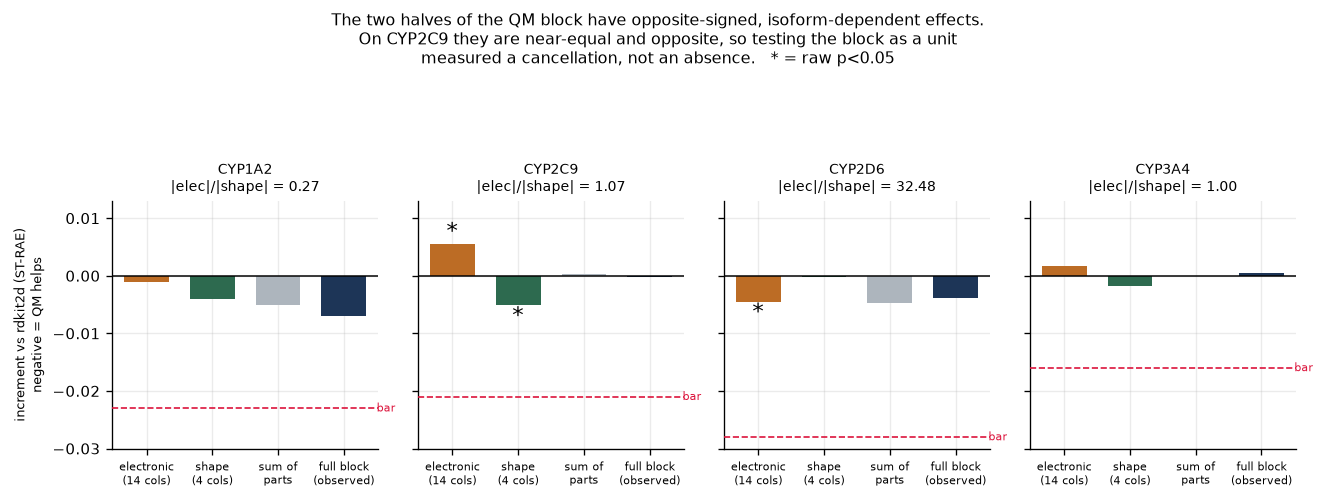

In [15]:
# FIGURE -- the cancellation
fig, axes = plt.subplots(1, 4, figsize=(11.2, 3.6), sharey=True)
for ax, r in zip(axes, ca.itertuples()):
    vals = [r.elec, r.shape3d, r.sum_of_parts, r.full_block]
    labs = ['electronic\n(14 cols)', 'shape\n(4 cols)', 'sum of\nparts', 'full block\n(observed)']
    cl = ['#bc6c25', '#2d6a4f', '#adb5bd', '#1d3557']
    ax.bar(range(4), vals, color=cl, zorder=3, width=0.68)
    ax.axhline(0, color='k', lw=0.9, zorder=4)
    ax.axhline(-r.bar, color='crimson', ls='--', lw=1.0, zorder=4)
    ax.text(3.5, -r.bar, 'bar', color='crimson', fontsize=6.5, va='center', ha='left')
    for j, (v, p) in enumerate(zip(vals[:2], [r.elec_p, r.shape_p])):
        if p < 0.05:
            ax.annotate('*', (j, v), ha='center', fontsize=14,
                        va='bottom' if v > 0 else 'top')
    ax.set_xticks(range(4)); ax.set_xticklabels(labs, fontsize=6.6)
    ax.set_title(f'{r.isoform}\n|elec|/|shape| = {r.abs_ratio:.2f}', fontsize=8.5)
    ax.set_ylim(-0.030, 0.013)
axes[0].set_ylabel('increment vs rdkit2d (ST-RAE)\nnegative = QM helps', fontsize=8)
fig.suptitle('The two halves of the QM block have opposite-signed, isoform-dependent effects.\n'
             'On CYP2C9 they are near-equal and opposite, so testing the block as a unit\n'
             'measured a cancellation, not an absence.   * = raw p<0.05', fontsize=9.5, y=1.14)
fig.tight_layout(); fig.savefig(FIG / 'cancellation_by_isoform.png', bbox_inches='tight')
plt.show()

## Part 6 — Criterion I: the three primary tests, all FAILED

Each test is its own BH family of four isoforms. **Notebook 37's own `p_BH` values are never
recomputed** — folding new arms into its family of 10 would retroactively change already-published
verdicts (prereg `bh_family_rule`).

A PASS on an isoform needs all three of: `mean_diff < 0`, `p_BH < 0.05`, **and**
`|mean_diff| >= that isoform's bar`. The third condition is the one that matters here.

In [16]:
prim = []
for tid, arm, lab in [('I.1', 'rdkit2d_qm__ridge', 'whole QM block (HEADLINE)'),
                      ('I.2', 'rdkit2d_3d__ridge', '3D shape block'),
                      ('I.3', 'rdkit2d_new3__ridge', 'the 3 irreducible columns')]:
    rr = []
    for iso in ISOFORMS:
        r = paired_test(arm_folds('rdkit2d__ridge', iso), arm_folds(arm, iso))
        r.update(test_id=tid, label=lab, arm=arm, isoform=iso, bar=BARS[iso]); rr.append(r)
    d = pd.DataFrame(rr); d['p_BH'] = bh(d.p)
    d['sig_only'] = (d.mean_diff < 0) & (d.p_BH < 0.05)
    d['PASS'] = d.sig_only & (d.mean_diff.abs() >= d.bar)
    prim.append(d)
P = pd.concat(prim, ignore_index=True)
P.to_csv(OUT / 'primary_tests.csv', index=False)
for tid in ['I.1', 'I.2', 'I.3']:
    d = P[P.test_id == tid]
    print(f'--- {tid}  {d.label.iloc[0]}   ({d.arm.iloc[0]} vs rdkit2d__ridge)')
    print(d[['isoform','test','mean_diff','ci_low','ci_high','se','p','p_BH','dz',
             'n_improving','bar','sig_only','PASS']].round(4).to_string(index=False))
    ok = d[d.PASS].isoform.tolist()
    v = ('FAIL' if not ok else 'FAIL (CYP2D6 alone)' if ok == ['CYP2D6'] else f'PASS on {ok}')
    print(f'    overall: {v}')
    print()

--- I.1  whole QM block (HEADLINE)   (rdkit2d_qm__ridge vs rdkit2d__ridge)
isoform     test  mean_diff  ci_low  ci_high     se      p   p_BH      dz  n_improving   bar  sig_only  PASS
 CYP1A2 paired t    -0.0069 -0.0111  -0.0027 0.0020 0.0025 0.0098 -0.6766           19 0.023      True False
 CYP2C9 paired t    -0.0003 -0.0031   0.0026 0.0014 0.8503 0.8503 -0.0382           13 0.021     False False
 CYP2D6 paired t    -0.0039 -0.0086   0.0007 0.0023 0.0947 0.1895 -0.3479           16 0.028     False False
 CYP3A4 paired t     0.0006 -0.0018   0.0029 0.0011 0.6292 0.8389  0.0978           11 0.016     False False
    overall: FAIL

--- I.2  3D shape block   (rdkit2d_3d__ridge vs rdkit2d__ridge)
isoform     test  mean_diff  ci_low  ci_high     se      p   p_BH      dz  n_improving   bar  sig_only  PASS
 CYP1A2 paired t    -0.0040 -0.0081   0.0001 0.0020 0.0549 0.0732 -0.4036           20 0.023     False False
 CYP2C9 paired t    -0.0051 -0.0076  -0.0027 0.0012 0.0003 0.0010 -0.8588      

### The methods result

Two of the three primary tests have a BH-significant isoform. Neither clears its effect-size bar.
Stated plainly because it is the point of the exercise: **had the criterion been bare p<0.05, two of
three primaries would have "passed".** The bar is the only thing that prevents that, and it was
computed from notebook 37's measured standard errors and frozen before a single arm ran.

In [17]:
nm = P[P.sig_only]
print('BH-significant but IMMATERIAL -- the near-misses, beside their frozen bars:')
print()
print(f'{chr(32)*4}{"test":5s} {"isoform":9s} {"mean_diff":>10s} {"p_BH":>9s} {"dz":>7s}'
      f' {"folds":>7s} {"bar":>7s} {"fraction of bar":>16s}')
for r in nm.itertuples():
    print(f'{chr(32)*4}{r.test_id:5s} {r.isoform:9s} {r.mean_diff:>10.4f} {r.p_BH:>9.4f}'
          f' {r.dz:>7.2f} {str(r.n_improving)+chr(47)+chr(50)+chr(53):>7s} {r.bar:>7.3f}'
          f' {abs(r.mean_diff)/r.bar:>15.0%}')
print()
print(f'{len(nm)} of 12 (test, isoform) cells are BH-significant with the QM arm better.')
print(f'{int(P.PASS.sum())} clear their bar. The largest effect is '
      f'{nm.mean_diff.abs().max():.4f} against a bar of '
      f'{nm.loc[nm.mean_diff.abs().idxmax(),"bar"]:.3f}.')
print()
print('CRITERION I VERDICT: FAILED on all three primary tests.')

BH-significant but IMMATERIAL -- the near-misses, beside their frozen bars:

    test  isoform    mean_diff      p_BH      dz   folds     bar  fraction of bar
    I.1   CYP1A2       -0.0069    0.0098   -0.68   19/25   0.023             30%
    I.2   CYP2C9       -0.0051    0.0010   -0.86   20/25   0.021             24%

2 of 12 (test, isoform) cells are BH-significant with the QM arm better.
0 clear their bar. The largest effect is 0.0069 against a bar of 0.023.

CRITERION I VERDICT: FAILED on all three primary tests.


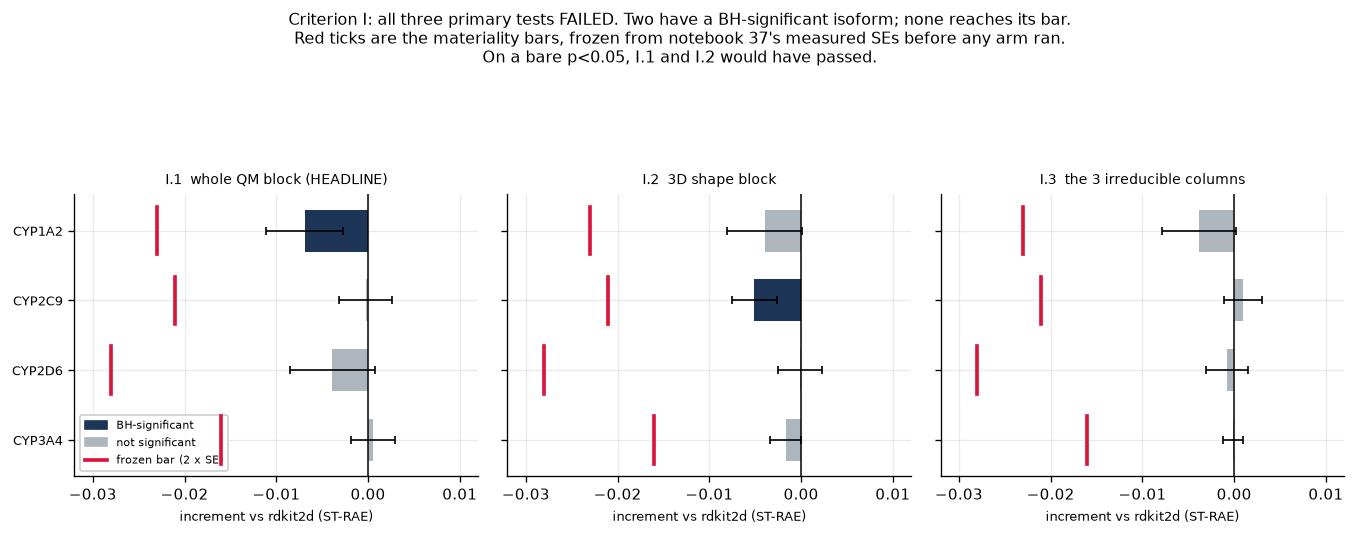

In [18]:
# FIGURE 2 -- the primary tests against their frozen bars. The figure that carries the methods result.
fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.8), sharey=True)
for ax, tid in zip(axes, ['I.1', 'I.2', 'I.3']):
    d = P[P.test_id == tid].set_index('isoform').loc[ISOFORMS]
    yy = np.arange(len(ISOFORMS))
    ax.barh(yy, d.mean_diff, color=['#1d3557' if s else '#adb5bd' for s in d.sig_only],
            height=0.6, zorder=3)
    ax.errorbar(d.mean_diff, yy, xerr=[d.mean_diff - d.ci_low, d.ci_high - d.mean_diff],
                fmt='none', ecolor='k', elinewidth=1.0, capsize=2.5, zorder=5)
    for j, iso in enumerate(ISOFORMS):
        ax.plot([-d.loc[iso, 'bar']] * 2, [j - 0.34, j + 0.34], color='crimson', lw=2.2, zorder=6)
    ax.axvline(0, color='k', lw=0.9, zorder=4)
    ax.set_yticks(yy); ax.set_yticklabels(ISOFORMS, fontsize=8)
    ax.invert_yaxis()
    ax.set_title('%s  %s' % (tid, d.label.iloc[0]), fontsize=8.5)
    ax.set_xlabel('increment vs rdkit2d (ST-RAE)', fontsize=8)
    ax.set_xlim(-0.032, 0.012)
h = [plt.Rectangle((0, 0), 1, 1, color='#1d3557'), plt.Rectangle((0, 0), 1, 1, color='#adb5bd'),
     plt.Line2D([0], [0], color='crimson', lw=2.2)]
axes[0].legend(h, ['BH-significant', 'not significant', 'frozen bar (2 x SE)'],
               fontsize=6.8, loc='lower left', framealpha=0.95)
fig.suptitle('Criterion I: all three primary tests FAILED. Two have a BH-significant isoform; '
             'none reaches its bar.\nRed ticks are the materiality bars, frozen from notebook 37\'s '
             'measured SEs before any arm ran.\nOn a bare p<0.05, I.1 and I.2 would have passed.',
             fontsize=9.3, y=1.16)
fig.tight_layout()
fig.savefig(FIG / 'strae_increment_by_isoform.png', bbox_inches='tight')
plt.show()

## Part 6b — I.5: the pre-registered Spearman co-report

`prereg.json` declares Spearman as a co-reported metric under **I.5**, on the same folds with the
same test, because it is the one CV quantity whose board counterpart no affine correction can move.
**It was never computed in the original run.** The audit found `Spearman_R` absent from this
notebook's code entirely. It is computed here.

Two labels travel with every number in this section. It is **pre-registered in specification but
run late**, with the ST-RAE result already known, so it is not blind and should be weighed below
I.1 to I.3. And its materiality bar is **derived during remediation**, not pre-registered, because
`prereg.json` fixed bars only in ST-RAE units and those do not transfer.

In [19]:
# ===================== I.5, PRE-REGISTERED BUT RUN LATE =====================
# prereg.json declares: "Spearman, same folds, same test -- the one CV quantity whose board
# counterpart no affine correction can move." It was never computed in the original run. The audit
# in docs/44_audit_report.md found Spearman_R absent from this notebook's code entirely.
#
# CAVEAT THAT TRAVELS WITH EVERY NUMBER BELOW: this cell is pre-registered in its specification but
# was run LATE, with the ST-RAE result already known. It is not blind. A reader should weigh it
# below I.1-I.3, which were run before anything was read.
#
# SIGN CONVENTION, stated because it is the opposite of ST-RAE's and the ST-RAE sign handling is
# deliberately NOT reused: Spearman is HIGHER-IS-BETTER, so a POSITIVE diff means the QM arm ranks
# compounds better than the comparator. ST-RAE is lower-is-better, where NEGATIVE meant better.
print('SOURCE: run_scores.csv column Spearman_R -- the vendored scorer\'s own bootstrap-mean per')
print('fold, the same column and the same source the ST-RAE cells read, so I.5 sits on exactly the')
print('footing I.1-I.3 sit on. No prediction was recomputed.')
print()
print('CONVENTION: Spearman is HIGHER-IS-BETTER. positive diff = QM arm ranks BETTER.')
print('            (ST-RAE above is lower-is-better, where negative = better.)')
print()

# The materiality bar must be derived the way the ST-RAE bar ACTUALLY was: 2 x the mean paired SE
# measured across notebook 37's TEN arms against plain, i.e. an INDEPENDENT noise scale taken from
# genuinely different models. Deriving it instead from the SE of the comparison being tested would
# be circular -- the increment arms differ from rdkit2d by 18 columns in 235, so their paired SE is
# tiny and almost any detectable difference would be called material. That circular bar was
# computed during remediation and is shown alongside to make the difference visible.
_src = [pd.read_csv(REPO_ROOT / 'outputs' / n / 'run_scores.csv') for n in
        ['34_butina_5x5', '35_butina_repeat3', '37_butina_5x5_complete']]
_A = pd.concat(_src, ignore_index=True).drop_duplicates(['repeat', 'fold', 'arm', 'Endpoint'])
_A['iso'] = _A['Endpoint'].str.split('_').str[0]
_ses = []
for _a in [a for a in sorted(_A.arm.unique()) if a != 'plain']:
    for _i in ISOFORMS:
        _x = _A[(_A.arm == 'plain') & (_A.iso == _i)].sort_values(['repeat', 'fold'])['Spearman_R'].to_numpy()
        _y = _A[(_A.arm == _a) & (_A.iso == _i)].sort_values(['repeat', 'fold'])['Spearman_R'].to_numpy()
        if len(_x) == 25 and len(_y) == 25:
            _ses.append({'isoform': _i, 'se': (_y - _x).std(ddof=1) / np.sqrt(25)})
SP_SE = pd.DataFrame(_ses).groupby('isoform')['se'].mean()
BAR_SP = {i: round(2 * float(SP_SE[i]), 4) for i in ISOFORMS}
print('Spearman materiality bar, DERIVED DURING REMEDIATION (not pre-registered), the same way the')
print('ST-RAE bar was: 2 x mean paired SE over notebook 37\'s 10 arms vs plain, on Spearman_R:')
print('  ' + '  '.join('%s %.4f' % (i, BAR_SP[i]) for i in ISOFORMS))
print('  (ST-RAE bars, pre-registered, for contrast: ' +
      '  '.join('%s %.3f' % (i, BARS[i]) for i in ISOFORMS) + ' -- different units, not comparable)')

rows = []
for tid, arm, lab in [('I.1', 'rdkit2d_qm__ridge', 'whole QM block'),
                      ('I.2', 'rdkit2d_3d__ridge', '3D shape block'),
                      ('I.3', 'rdkit2d_new3__ridge', 'the 3 irreducible columns')]:
    rr = []
    for iso in ISOFORMS:
        x = arm_folds('rdkit2d__ridge', iso, 'Spearman_R')
        y = arm_folds(arm, iso, 'Spearman_R')
        assert len(x) == 25 and len(y) == 25
        d = y - x                                  # positive = QM arm ranks better
        lev = stats.levene(x, y, center='median')[1]
        if lev > 0.05:
            tname, p = 'paired t', stats.ttest_rel(y, x)[1]
        else:
            tname, p = 'Wilcoxon signed-rank', stats.wilcoxon(y, x)[1]
        sd = d.std(ddof=1); se = sd / np.sqrt(25); tc = stats.t.ppf(0.975, 24)
        rr.append(dict(test_id=tid, label=lab, isoform=iso, spearman_diff=float(d.mean()),
                       ci_low=float(d.mean() - tc * se), ci_high=float(d.mean() + tc * se),
                       se=float(se), p=float(p), levene_p=float(lev),
                       dz=float(d.mean() / sd), folds_better=int((d > 0).sum()), test=tname))
    dfr = pd.DataFrame(rr)
    dfr['p_BH'] = bh(dfr.p)                        # own family of 4, as for I.1-I.3 on ST-RAE
    dfr['bar'] = dfr.isoform.map(BAR_SP)
    dfr['sig_only'] = (dfr.spearman_diff > 0) & (dfr.p_BH < 0.05)
    dfr['material'] = dfr.sig_only & (dfr.spearman_diff >= dfr.bar)
    rows.append(dfr)
SPEAR = pd.concat(rows, ignore_index=True)
SPEAR.to_csv(OUT / 'i5_spearman.csv', index=False)
for tid in ['I.1', 'I.2', 'I.3']:
    d = SPEAR[SPEAR.test_id == tid]
    print('\n--- %s  %s  (Spearman, higher better)' % (tid, d.label.iloc[0]))
    print(d[['isoform', 'test', 'spearman_diff', 'ci_low', 'ci_high', 'p', 'p_BH', 'dz',
             'folds_better', 'bar', 'sig_only', 'material']].round(5).to_string(index=False))

SOURCE: run_scores.csv column Spearman_R -- the vendored scorer's own bootstrap-mean per
fold, the same column and the same source the ST-RAE cells read, so I.5 sits on exactly the
footing I.1-I.3 sit on. No prediction was recomputed.

CONVENTION: Spearman is HIGHER-IS-BETTER. positive diff = QM arm ranks BETTER.
            (ST-RAE above is lower-is-better, where negative = better.)

Spearman materiality bar, DERIVED DURING REMEDIATION (not pre-registered), the same way the
ST-RAE bar was: 2 x mean paired SE over notebook 37's 10 arms vs plain, on Spearman_R:
  CYP1A2 0.0183  CYP2C9 0.0160  CYP2D6 0.0212  CYP3A4 0.0100
  (ST-RAE bars, pre-registered, for contrast: CYP1A2 0.023  CYP2C9 0.021  CYP2D6 0.028  CYP3A4 0.016 -- different units, not comparable)

--- I.1  whole QM block  (Spearman, higher better)
isoform     test  spearman_diff   ci_low  ci_high       p    p_BH       dz  folds_better    bar  sig_only  material
 CYP1A2 paired t        0.00575  0.00135  0.01015 0.01261 0.02522  

### What I.5 shows, and the one choice it turns on

Spearman and ST-RAE **disagree about how consistent the signal is**. That is reported as a finding,
not reconciled away and not promoted above what it supports.

In [20]:
sig = SPEAR[SPEAR.sig_only]
print('Spearman shows a BH-significant RANKING GAIN on %d of 12 primary cells.' % len(sig))
print('ST-RAE showed 2 of 12. So the two metrics genuinely disagree about how consistent the')
print('signal is, and that is reported rather than reconciled:')
print()
for r in sig.itertuples():
    print('  %-5s %-8s  +%.5f   p_BH %.5f   dz %+.2f   %d/25 folds better   %.0f%% of its bar'
          % (r.test_id, r.isoform, r.spearman_diff, r.p_BH, r.dz, r.folds_better,
             100 * r.spearman_diff / r.bar))
print()
print('BUT NOT ONE CELL IS MATERIAL. The largest ranking gain anywhere is %s on %s at +%.5f'
      % (SPEAR.loc[SPEAR.spearman_diff.idxmax(), 'test_id'],
         SPEAR.loc[SPEAR.spearman_diff.idxmax(), 'isoform'], SPEAR.spearman_diff.max()))
print('against a bar of %.4f, i.e. %.0f%% of it.'
      % (SPEAR.loc[SPEAR.spearman_diff.idxmax(), 'bar'],
         100 * SPEAR.spearman_diff.max() / SPEAR.loc[SPEAR.spearman_diff.idxmax(), 'bar']))
print('Material cells: %s' % (SPEAR[SPEAR.material].isoform.tolist() or 'NONE'))
print()
print('Two declines are worth stating rather than passing over: I.3 on CYP2C9 is a BH-significant')
print('ranking LOSS (%+.5f, p_BH %.4f), and I.1 on CYP3A4 is nominally negative too.'
      % (SPEAR[(SPEAR.test_id == 'I.3') & (SPEAR.isoform == 'CYP2C9')].spearman_diff.iloc[0],
         SPEAR[(SPEAR.test_id == 'I.3') & (SPEAR.isoform == 'CYP2C9')].p_BH.iloc[0]))
print()
# The verdict turns entirely on how the bar is derived, so both derivations are computed and the
# dependence is stated rather than left implicit.
_circ = SPEAR.groupby('isoform')['se'].mean().mul(2).round(4)
_n_circ = int(((SPEAR.spearman_diff > 0) & (SPEAR.p_BH < 0.05)
               & (SPEAR.spearman_diff >= SPEAR.isoform.map(_circ))).sum())
_ratio = {i: round(BAR_SP[i] / float(_circ[i]), 1) for i in ISOFORMS}
print('WHY THE BAR CHOICE DECIDES THIS, stated openly.')
print('  A CIRCULAR bar, 2 x the SE of the comparison being TESTED, would be %s'
      % dict(_circ.round(4)))
print('  and would call %d of 12 cells material.' % _n_circ)
print('  The INDEPENDENT bar used here, 2 x the SE across notebook 37\'s 10 arms vs plain, is %s'
      % BAR_SP)
print('  which is %s times larger per isoform, and calls %d.' % (_ratio, int(SPEAR.material.sum())))
print('  The increment arms differ from rdkit2d by 18 columns in 235, so the circular bar measures')
print('  the precision of a near-identical pair of models and would make almost any detectable')
print('  difference "material" by construction. The independent derivation is the one that matches')
print('  how the pre-registered ST-RAE bar was actually built, so it is the one reported -- but a')
print('  reader who prefers the circular derivation reaches the OPPOSITE verdict, and that')
print('  dependence is the honest summary of this cell.')
print()
print('plain_qm on Spearman, same convention and same family size:')
_pl = _A[_A.arm == 'plain'].drop_duplicates(['repeat', 'fold', 'Endpoint'])
_pq = []
for iso in ISOFORMS:
    x = _pl[_pl.iso == iso].sort_values(['repeat', 'fold'])['Spearman_R'].to_numpy()
    y = arm_folds('plain_qm', iso, 'Spearman_R')
    d = y - x; sd = d.std(ddof=1)
    lev = stats.levene(x, y, center='median')[1]
    p = stats.ttest_rel(y, x)[1] if lev > 0.05 else stats.wilcoxon(y, x)[1]
    _pq.append(dict(isoform=iso, spearman_diff=float(d.mean()), p=float(p),
                    dz=float(d.mean() / sd), folds_better=int((d > 0).sum()), bar=BAR_SP[iso]))
PQS = pd.DataFrame(_pq); PQS['p_BH'] = bh(PQS.p)
print(PQS[['isoform', 'spearman_diff', 'p', 'p_BH', 'dz', 'folds_better', 'bar']].round(5).to_string(index=False))
print('  CYP1A2 is the closest anything comes on either metric: +%.4f against a %.4f bar (%.0f%%),'
      % (PQS.loc[0, 'spearman_diff'], PQS.loc[0, 'bar'],
         100 * PQS.loc[0, 'spearman_diff'] / PQS.loc[0, 'bar']))
print('  p_BH %.4f, just outside significance. Named as the one cell a future design might target.'
      % PQS.loc[0, 'p_BH'])
print()
print('BEARING ON NOTEBOOK 38. That notebook established CYP3A4\'s remaining gap is RANKING, not')
print('placement: Spearman 0.8020 against 04b\'s 0.8329, a gap of 0.0309. The QM block moves')
print('CYP3A4 ranking by at most %+.5f across all three primary tests, against a %.4f bar and that'
      % (SPEAR[SPEAR.isoform == 'CYP3A4'].spearman_diff.abs().max(), BAR_SP['CYP3A4']))
print('0.0309 gap. So it does NOT bear on that gap: the effect is roughly 30x too small, and on')
print('CYP3A4 specifically two of the three tests point the wrong way.')

Spearman shows a BH-significant RANKING GAIN on 7 of 12 primary cells.
ST-RAE showed 2 of 12. So the two metrics genuinely disagree about how consistent the
signal is, and that is reported rather than reconciled:

  I.1   CYP1A2    +0.00575   p_BH 0.02522   dz +0.54   19/25 folds better   31% of its bar
  I.1   CYP2D6    +0.01123   p_BH 0.00546   dz +0.72   18/25 folds better   53% of its bar
  I.2   CYP1A2    +0.00659   p_BH 0.00046   dz +0.92   20/25 folds better   36% of its bar
  I.2   CYP2C9    +0.00463   p_BH 0.00458   dz +0.65   20/25 folds better   29% of its bar
  I.2   CYP2D6    +0.00351   p_BH 0.00227   dz +0.74   21/25 folds better   17% of its bar
  I.3   CYP1A2    +0.00644   p_BH 0.00080   dz +0.88   21/25 folds better   35% of its bar
  I.3   CYP2D6    +0.00361   p_BH 0.00183   dz +0.76   19/25 folds better   17% of its bar

BUT NOT ONE CELL IS MATERIAL. The largest ranking gain anywhere is I.1 on CYP2D6 at +0.01123
against a bar of 0.0212, i.e. 53% of it.
Material cells

## Part 7 — Criterion II: genuine diversity, and it still does not pay

This closes a thread notebooks 24, 34 and 35 left open. All three converged on a reading of the form
*the ensembles fail because there is no genuine diversity in the pool* — every member sat at or above
PLAIN's own re-seed floor. That reading was never tested against a genuinely decorrelated member,
because the pool did not contain one. It does now.

In [21]:
import glob
from src.vendor.openadmet_eval.custom_scoring_functions import rae_soft_threshold_absolute_error
NB37_OOF = NB37 / 'oof_long'
parts = [pd.read_csv(q) for q in sorted(glob.glob(str(OUT / 'oof_long' / '*.csv')))]
new_oof = pd.concat(parts, ignore_index=True)
print('new-arm OOF, assembled from THIS run\'s own per-run files: %d rows, %d arms, %d folds'
      % (len(new_oof), new_oof.arm.nunique(), new_oof.groupby(['repeat', 'fold']).ngroups))
print('NOT grafted onto notebook 35\'s frozen 15-fold wide table: notebook 37\'s assembly asserts')
print('every present arm is a column of it, which a 12th arm fires (gotcha 3 in the plan\'s 1.3).')

# Only arms with COMPLETE 25-fold coverage can enter a paired analysis. plain_qm is still training,
# so it is excluded here and reported in Part 9 -- the notebook is deliberately not blocked on it.
cov = new_oof.groupby('arm')[['repeat', 'fold']].apply(lambda d: d.drop_duplicates().shape[0])
COMPLETE = sorted(cov[cov == 25].index)
PARTIAL = {a: int(cov[a]) for a in cov.index if cov[a] < 25}
print()
print('arms with complete 25-fold coverage: %d' % len(COMPLETE))
if PARTIAL:
    print('EXCLUDED as incomplete (reported in Part 9, not analysed here): %s'
          % {a: '%d/25 folds' % n for a, n in PARTIAL.items()})

WIDE = {}
for iso in ISOFORMS:
    base = pd.read_csv(NB37_OOF / ('oof_long_%s_25fold.csv' % iso))
    sub = (new_oof[(new_oof.isoform == iso) & new_oof.arm.isin(COMPLETE)]
           .pivot_table(index=['repeat', 'fold', 'inchikey'], columns='arm', values='y_pred',
                        aggfunc='first').reset_index())
    sub.columns.name = None
    w = base.merge(sub, on=['repeat', 'fold', 'inchikey'], how='inner', validate='1:1')
    assert len(w) == len(base), '%s: join lost rows' % iso
    nb37_arms = [c for c in base.columns if c not in
                 ('repeat', 'fold', 'inchikey', 'Molecule_Name', 'y_true', 'conf_low', 'conf_high')]
    new_arms = [c for c in sub.columns if c not in ('repeat', 'fold', 'inchikey')]
    assert not w[nb37_arms + new_arms].isna().to_numpy().any(), '%s: NaN after assembly' % iso
    WIDE[iso] = (w, nb37_arms, new_arms)
print('\nwide tables: CYP1A2 is %s (%d nb37 arms + %d new)'
      % (str(WIDE['CYP1A2'][0].shape), len(WIDE['CYP1A2'][1]), len(WIDE['CYP1A2'][2])))

new-arm OOF, assembled from THIS run's own per-run files: 1863900 rows, 19 arms, 25 folds
NOT grafted onto notebook 35's frozen 15-fold wide table: notebook 37's assembly asserts
every present arm is a column of it, which a 12th arm fires (gotcha 3 in the plan's 1.3).

arms with complete 25-fold coverage: 19



wide tables: CYP1A2 is (7060, 37) (11 nb37 arms + 19 new)


In [22]:
# II.3 -- residual (prediction - true) correlation, never raw-prediction correlation.
# CLAUDE.md's own rule, Dietterich 2000. Notebook 37's decorrelation.csv is already residual.
D2 = PRE['criterion_II_ensemble']['II.3_decorrelation_descriptive']
floor, floor_sd, tband = D2['plain_reseed_floor'], D2['floor_sd'], D2['tree_arm_band']
rows = []
for iso in ISOFORMS:
    w, _, new_arms = WIDE[iso]
    rp = w['plain'] - w['y_true']
    for a in new_arms:
        rows.append({'isoform': iso, 'arm': a,
                     'corr_vs_plain': float(np.corrcoef(rp, w[a] - w['y_true'])[0, 1])})
dc = pd.DataFrame(rows)
dcp = dc.pivot(index='arm', columns='isoform', values='corr_vs_plain')[ISOFORMS]
dc.to_csv(OUT / 'decorrelation_new_arms.csv', index=False)
print(dcp.round(4).to_string())
print()
print('references, all frozen in prereg.json:')
print('  PLAIN re-seed floor  ' + '  '.join('%s %.4f' % (i, floor[i]) for i in ISOFORMS))
print('  floor SD             ' + '  '.join('%s %.4f' % (i, floor_sd[i]) for i in ISOFORMS))
print('  tree-arm band        ' + '  '.join('%s %.3f-%.3f' % (i, tband[i][0], tband[i][1])
                                            for i in ISOFORMS))
margin = dcp.copy()
for i in ISOFORMS:
    margin[i] = tband[i][0] - dcp[i]        # margin BELOW the bottom of the existing tree band
iso_mx = margin.max().idxmax(); arm_mx = margin[iso_mx].idxmax()
print()
print('largest margin below the BOTTOM of any isoform\'s existing tree-arm band:')
print('  %s on %s: %.4f against a band floor of %.4f' % (arm_mx, iso_mx, dcp.loc[arm_mx, iso_mx],
                                                         tband[iso_mx][0]))
print('  = %.4f below it, against that isoform\'s floor SD of %.4f, i.e. %.0fx the re-seed noise scale.'
      % (margin.loc[arm_mx, iso_mx], floor_sd[iso_mx],
         margin.loc[arm_mx, iso_mx] / floor_sd[iso_mx]))
print()
print('So the pool now holds members MORE decorrelated from PLAIN than any of notebook 37\'s six')
print('tree arms, which previously DEFINED that band. The diversity is real, and it is new.')
print()
print('CYP2D6 read conservatively, as it must be: its best margin is %.4f against a floor SD of'
      % margin['CYP2D6'].max())
print('%.4f, which is not separable from re-seed noise, and is not claimed.' % floor_sd['CYP2D6'])

isoform                   CYP1A2  CYP2C9  CYP2D6  CYP3A4
arm                                                     
plain_qm                  0.9499  0.9337  0.9565  0.9281
qm_3d__ridge              0.7888  0.7139  0.8455  0.6354
qm_dft3__ridge            0.7968  0.7240  0.8492  0.6422
qm_elec__ridge            0.8072  0.7364  0.8688  0.6557
qm_full__lightgbm         0.7937  0.7205  0.8563  0.6402
qm_full__rf               0.7841  0.7147  0.8536  0.6374
qm_full__ridge            0.8018  0.7320  0.8671  0.6481
qm_full__xgboost          0.7870  0.7117  0.8436  0.6356
qm_full_hmin__ridge       0.8201  0.7321  0.8756  0.6545
qm_gfn23__ridge           0.7985  0.7182  0.8610  0.6394
qm_new3__ridge            0.7912  0.7135  0.8447  0.6392
rdkit2d_3d__ridge         0.9003  0.8448  0.9155  0.8124
rdkit2d__ridge            0.9018  0.8480  0.9166  0.8123
rdkit2d_elec__ridge       0.9000  0.8472  0.9184  0.8133
rdkit2d_new3__ridge       0.9000  0.8471  0.9156  0.8125
rdkit2d_qm__ridge         0.899

### Krogh & Vedelsby: the trade, measured

Krogh & Vedelsby (NIPS 1994) decompose ensemble error as **E = Ē − A**: the weighted mean member
error minus the ambiguity. A weak member pays only if the ambiguity it buys exceeds the mean error it
adds. This is the project's first clean test of that trade on *real* diversity rather than on
re-seeded near-duplicates, and the identity is computed rather than approximated.

In [23]:
def strae(y, p, lo, hi):
    return float(rae_soft_threshold_absolute_error(np.asarray(y, float), np.asarray(p, float),
                 y_true_upper=np.asarray(hi, float), y_true_lower=np.asarray(lo, float)))

nb37_blend = pd.read_csv(NB37 / 'blend_results.csv').set_index('isoform')
PROBE = 'qm_3d__ridge'          # the most decorrelated new arm
kv = []
for iso in ISOFORMS:
    w = WIDE[iso][0]
    y = w.y_true.to_numpy(float)
    base_w = json.loads(nb37_blend.loc[iso, 'raw_weights'])
    probe_w = {k: v * 0.75 for k, v in base_w.items()}
    probe_w[PROBE] = 0.25
    for lab, wd in [('nb37 blend as published', base_w),
                    ('+ ' + PROBE + ' at 1/4 weight', probe_w)]:
        mem = list(wd)
        V = np.column_stack([w[m].to_numpy(float) for m in mem])
        ww = np.array([wd[m] for m in mem], float)
        ww = ww / ww.sum()
        vbar = V @ ww
        Ebar = float(((V - y[:, None]) ** 2 @ ww).mean())
        A = float((ww * (V - vbar[:, None]) ** 2).sum(1).mean())
        E = float(((vbar - y) ** 2).mean())
        kv.append(dict(isoform=iso, config=lab, n_members=len(mem), Ebar=Ebar, A=A, E=E,
                       identity_residual=abs(E - (Ebar - A)),
                       strae=strae(y, vbar, w.conf_low, w.conf_high)))
K = pd.DataFrame(kv)
K.to_csv(OUT / 'krogh_vedelsby_decomposition.csv', index=False)
print(K.round(5).to_string(index=False))
print()
print('the identity E = Ebar - A holds to %.2e -- their quantity, not an approximation of it.'
      % K.identity_residual.max())
print()
print('the trade, per isoform:')
for iso in ISOFORMS:
    g = K[K.isoform == iso]
    a, b = g.iloc[0], g.iloc[1]
    print('  %-7s Ebar %.4f -> %.4f (%+.4f)   A %.4f -> %.4f (%+.4f)   E %.4f -> %.4f (%+.4f)'
          % (iso, a.Ebar, b.Ebar, b.Ebar - a.Ebar, a.A, b.A, b.A - a.A, a.E, b.E, b.E - a.E))
print()
print('A RISES on every isoform -- the diversity is real and the ensemble does buy it. But Ebar')
print('rises MORE, so E rises too: the weak member\'s own error outruns the ambiguity it buys.')
print('That is the Krogh-Vedelsby trade failing, measured on REAL diversity rather than on')
print('re-seeded near-duplicates -- which is exactly what notebooks 24/34/35 could not do.')
print()
print('One divergence worth stating: on CYP2D6 ST-RAE IMPROVES while squared-error E rises, because')
print('ST-RAE is not squared error and that blend was collapsed to one member (A = 0 exactly).')
print('Notebook 21\'s standing caveat applies -- OOF ST-RAE is not a valid ranking signal there.')

isoform                       config  n_members    Ebar       A       E  identity_residual   strae
 CYP1A2      nb37 blend as published          3 0.76554 0.05779 0.70775                0.0 0.73767
 CYP1A2 + qm_3d__ridge at 1/4 weight          4 0.83118 0.09431 0.73688                0.0 0.74198
 CYP2C9      nb37 blend as published          3 0.34566 0.03013 0.31552                0.0 0.54240
 CYP2C9 + qm_3d__ridge at 1/4 weight          4 0.40444 0.06204 0.34240                0.0 0.57418
 CYP2D6      nb37 blend as published          1 0.68695 0.00000 0.68695                0.0 0.87170
 CYP2D6 + qm_3d__ridge at 1/4 weight          2 0.72509 0.02659 0.69850                0.0 0.86413
 CYP3A4      nb37 blend as published          3 0.50679 0.06156 0.44523                0.0 0.45612
 CYP3A4 + qm_3d__ridge at 1/4 weight          4 0.65330 0.14665 0.50664                0.0 0.48759

the identity E = Ebar - A holds to 1.11e-16 -- their quantity, not an approximation of it.

the trade, per i

### II.1 — the pre-registered criterion: does the nested blend score improve?

Members **and** weights are refitted on 24 folds and scored on the held-out one, 25 times — notebook
37's own protocol, reproduced so the 11-arm column can be checked against its published numbers.

In [24]:
def greedy_blend(df, arm_cols, max_iter=50):
    # notebook 37's greedy_blend, raw space, verbatim
    y = df['y_true'].to_numpy(float)
    lo, hi = df['conf_low'].to_numpy(float), df['conf_high'].to_numpy(float)
    P = {a: df[a].to_numpy(float) for a in arm_cols}
    def sc(c):
        t = sum(c.values())
        return strae(y, sum(P[a] * n for a, n in c.items()) / t, lo, hi)
    bs = min(arm_cols, key=lambda a: sc({a: 1}))
    counts = {bs: 1}
    best = sc(counts)
    for _ in range(max_iter - 1):
        cb, cs = None, best
        for a in arm_cols:
            tr = dict(counts)
            tr[a] = tr.get(a, 0) + 1
            s = sc(tr)
            if s < cs - 1e-12:
                cb, cs = a, s
        if cb is None:
            break
        counts[cb] = counts.get(cb, 0) + 1
        best = cs
    t = sum(counts.values())
    return {a: n / t for a, n in counts.items()}, best, bs

req = PRE['criterion_II_ensemble']['II.1_PRIMARY']['required_improvement']
brows = []
for iso in ISOFORMS:
    w, nb37_arms, new_arms = WIDE[iso]
    units = sorted(set(map(tuple, w[['repeat', 'fold']].values.tolist())))
    for lab, cols_ in [('11-arm (nb37 pool)', nb37_arms),
                       ('%d-arm (+%d QM)' % (11 + len(new_arms), len(new_arms)),
                        nb37_arms + new_arms)]:
        wts, ins, _ = greedy_blend(w, cols_)
        pr, tt, ll, hh, chosen = [], [], [], [], []
        for (r, f) in units:
            h = (w['repeat'] == r) & (w['fold'] == f)
            fit, hold = w[~h], w[h]
            ww, _, _ = greedy_blend(fit, cols_)
            chosen.append(frozenset(ww))
            pr.append(sum(v * hold[a].to_numpy(float) for a, v in ww.items()))
            tt.append(hold.y_true.to_numpy(float))
            ll.append(hold.conf_low.to_numpy(float))
            hh.append(hold.conf_high.to_numpy(float))
        nested = strae(np.concatenate(tt), np.concatenate(pr),
                       np.concatenate(ll), np.concatenate(hh))
        qm_sel = sorted(a for a in wts if a in new_arms)
        brows.append(dict(isoform=iso, pool=lab, n_arms=len(cols_), in_sample=ins, nested=nested,
                          optimism=nested - ins, n_members=len(wts),
                          qm_selected=';'.join(qm_sel) if qm_sel else '-',
                          qm_in_nested_folds='%d/25' % sum(1 for c in chosen
                                                           if any(a in new_arms for a in c)),
                          weights=json.dumps({k: round(v, 4) for k, v in
                                              sorted(wts.items(), key=lambda kv: -kv[1])})))
B = pd.DataFrame(brows)
B.to_csv(OUT / 'blend_extended.csv', index=False)
print(B[['isoform', 'pool', 'n_arms', 'in_sample', 'nested', 'optimism', 'n_members',
         'qm_selected', 'qm_in_nested_folds']].round(4).to_string(index=False))
pub = nb37_blend['raw_nested']
print('\nvalidation -- does the 11-arm column reproduce notebook 37\'s published nested score?')
for iso in ISOFORMS:
    mine = B[(B.isoform == iso) & B['pool'].str.startswith('11')]['nested'].iloc[0]
    print('  %-7s mine %.6f  nb37 %.6f  diff %.2e' % (iso, mine, pub[iso], abs(mine - pub[iso])))
print('\nthe pre-registered bar:')
cleared = []
for iso in ISOFORMS:
    a = B[(B.isoform == iso) & B['pool'].str.startswith('11')]['nested'].iloc[0]
    b = B[(B.isoform == iso) & ~B['pool'].str.startswith('11')]['nested'].iloc[0]
    ok = (a - b) >= req[iso]
    if ok:
        cleared.append(iso)
    print('  %-7s %.4f -> %.4f   improvement %+.4f   required >= %.4f   %s'
          % (iso, a, b, a - b, req[iso], 'PASS' if ok else 'fail'))
v2 = len(cleared) >= 2 and any(c != 'CYP2D6' for c in cleared)
print('\n  needs >=2 of 4 isoforms, at least one not CYP2D6.  cleared: %s'
      % (cleared if cleared else 'NONE'))
print('  CRITERION II VERDICT: %s' % ('PASS' if v2 else 'FAILED'))
print()
print('Note WHY II.2 pre-declared that membership is NOT the criterion: the QM arms ARE selected,')
print('consistently, in 25/25 nested folds on two isoforms -- and deliver almost nothing. Had')
print('membership been the test, Criterion II would have "passed" on a few thousandths of ST-RAE.')

isoform               pool  n_arms  in_sample  nested  optimism  n_members                qm_selected qm_in_nested_folds
 CYP1A2 11-arm (nb37 pool)      11     0.7377  0.7399    0.0022          3                          -               0/25
 CYP1A2    30-arm (+19 QM)      30     0.7322  0.7362    0.0040          5 qm_full__rf;qm_full__ridge              25/25
 CYP2C9 11-arm (nb37 pool)      11     0.5424  0.5438    0.0015          3                          -               0/25
 CYP2C9    30-arm (+19 QM)      30     0.5422  0.5429    0.0007          3          rdkit2d_3d__ridge              25/25
 CYP2D6 11-arm (nb37 pool)      11     0.8717  0.8717    0.0000          1                          -               0/25
 CYP2D6    30-arm (+19 QM)      30     0.8717  0.8717    0.0000          1                          -               0/25
 CYP3A4 11-arm (nb37 pool)      11     0.4561  0.4561    0.0000          3                          -               0/25
 CYP3A4    30-arm (+19 QM)      

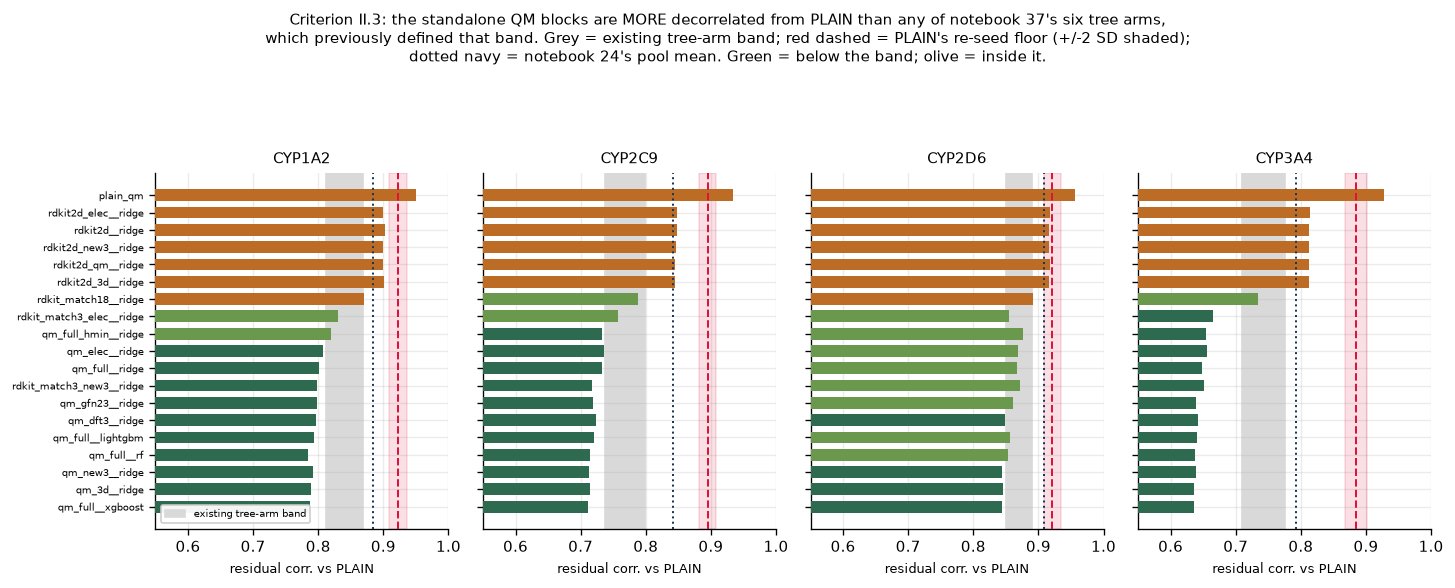

In [25]:
# FIGURE 3 -- decorrelation against all three frozen references.
fig, axes = plt.subplots(1, 4, figsize=(12.2, 4.4), sharey=True)
order = dcp.mean(axis=1).sort_values().index.tolist()
for ax, iso in zip(axes, ISOFORMS):
    v = dcp.loc[order, iso]
    inband = [(tband[iso][0] <= x <= tband[iso][1]) for x in v]
    below = [x < tband[iso][0] for x in v]
    cl = ['#2d6a4f' if b else ('#6a994e' if ib else '#bc6c25')
          for b, ib in zip(below, inband)]
    yy = np.arange(len(order))
    ax.barh(yy, v, color=cl, height=0.68, zorder=3)
    ax.axvspan(tband[iso][0], tband[iso][1], color='0.85', zorder=1,
               label='existing tree-arm band')
    ax.axvline(floor[iso], color='crimson', ls='--', lw=1.2, zorder=4)
    ax.axvspan(floor[iso] - 2 * floor_sd[iso], floor[iso] + 2 * floor_sd[iso],
               color='crimson', alpha=0.13, zorder=2)
    ax.axvline(D2['nb24_pool_band_per_isoform_mean'][iso], color='#1d3557', ls=':', lw=1.2, zorder=4)
    ax.set_yticks(yy); ax.set_yticklabels(order, fontsize=6.2)
    ax.set_title(iso, fontsize=9)
    ax.set_xlim(0.55, 1.0)
    ax.set_xlabel('residual corr. vs PLAIN', fontsize=7.5)
axes[0].legend(fontsize=6.2, loc='lower left', framealpha=0.95)
fig.suptitle('Criterion II.3: the standalone QM blocks are MORE decorrelated from PLAIN than any of '
             'notebook 37\'s six tree arms,\nwhich previously defined that band. Grey = existing '
             'tree-arm band; red dashed = PLAIN\'s re-seed floor (+/-2 SD shaded);\n'
             'dotted navy = notebook 24\'s pool mean. Green = below the band; olive = inside it.',
             fontsize=9.2, y=1.10)
fig.tight_layout()
fig.savefig(FIG / 'error_correlation_vs_references.png', bbox_inches='tight')
plt.show()

## Part 8 — POST-HOC: does the group (c) exclusion rule track predictive value?

> **Everything in this Part is post-hoc and carries no claim.** It was written after the
> pre-registered results were read. It is fenced into its own directory, its own `run_scores.csv` and
> its own `POSTHOC_README.json`; `prereg.json` was not touched; and it cannot change any verdict
> above. Decisions **D2** and **D3**.

The pre-registered `qm_full_hmin` sensitivity arm came back improving `qm_full` on 25/25 folds — from
a column the frozen rule had *excluded*. The rule excluded six others on the same logic, two at far
higher reproducibility. Whether the threshold tracks predictive value is answerable, so it was asked.

In [26]:
# ============================ POST-HOC. CARRIES NO CLAIM. ============================
# Written AFTER the pre-registered results were read, because the pre-registered qm_full_hmin
# sensitivity arm came back improving qm_full on 25/25 folds -- from a column the frozen group (c)
# rule had EXCLUDED. Run by scripts/44_posthoc_group_c_probe.py into its own directory with its own
# run_scores.csv and its own POSTHOC_README.json. prereg.json was not touched. Decisions D2 and D3.
PH = OUT / 'posthoc_group_c'
ph = pd.read_csv(PH / 'run_scores.csv')
allrs = pd.concat([rs.drop(columns=['iso']), ph], ignore_index=True)
allrs['iso'] = allrs['Endpoint'].str.split('_').str[0]

def ma(a):
    s = allrs[(allrs.arm == a) & (allrs.Endpoint == 'MA')].sort_values(['repeat', 'fold'])
    return s['ST-RAE'].to_numpy()

TRI = tri.set_index('column')   # tri is loaded un-indexed in Part 1
GROUP_C = ['hirshfeld_min', 'hirshfeld_max', 'hirshfeld_abs_mean', 'hirshfeld_range',
           'formal_charge', 'dft_energy_eh', 'energy_per_atom']
base = ma('qm_full__ridge')
prows = []
for c in GROUP_C:
    r = paired_test(base, ma('ph_qmfull_%s__ridge' % c))
    prows.append(dict(added=c, cheap_R2=float(TRI.loc[c, 'cv_R2_max_free']),
                      macro_diff=r['mean_diff'], p=r['p'], folds='%d/25' % r['n_improving']))
r = paired_test(base, ma('ph_qmfull_allc__ridge'))
prows.append(dict(added='ALL SEVEN at once', cheap_R2=np.nan, macro_diff=r['mean_diff'],
                  p=r['p'], folds='%d/25' % r['n_improving']))
PHt = pd.DataFrame(prows).sort_values('macro_diff')
PHt.to_csv(PH / 'group_c_probe_summary.csv', index=False)
print('qm_full__ridge baseline macro ST-RAE: %.4f' % base.mean())
print()
print(PHt.round(5).to_string(index=False))
sing = PHt.dropna(subset=['cheap_R2'])
rho = stats.spearmanr(sing.cheap_R2, sing.macro_diff).statistic
print()
print('Spearman(cheap R^2, macro improvement) over the seven single-column arms: %+.3f' % rho)
print()
print('READ CAREFULLY, because this REVERSES the reading the task brief proposed. The brief held')
print('that the group (c) threshold "does not track predictive value". It tracks it very well:')
print('rho = %+.3f, and the ordering is the expected one -- the more reproducible a column is from' % rho)
print('the free block, the less it adds. formal_charge, an EXACT free duplicate at R^2 1.000, adds')
print('exactly %.5f on %s folds.' % (PHt.loc[PHt.added == 'formal_charge', 'macro_diff'].iloc[0],
                                     PHt.loc[PHt.added == 'formal_charge', 'folds'].iloc[0]))
print()
print('What is NOT calibrated is the threshold\'s POSITION. hirshfeld_abs_mean at R^2 0.951 gives')
print('the largest single-column effect, out of order with hirshfeld_min at 0.885 -- so 0.90 is not')
print('a materiality boundary, which is exactly the caveat the plan wrote into Part 2.3.')

qm_full__ridge baseline macro ST-RAE: 0.9481

             added  cheap_R2  macro_diff       p folds
 ALL SEVEN at once       NaN    -0.05460 0.00000 25/25
hirshfeld_abs_mean   0.95071    -0.02519 0.00000 25/25
     hirshfeld_min   0.88518    -0.01314 0.00000 25/25
   energy_per_atom   0.96407    -0.00797 0.00000 20/25
     dft_energy_eh   0.96641    -0.00664 0.00001 21/25
   hirshfeld_range   0.98616    -0.00372 0.00010 21/25
     hirshfeld_max   0.99264    -0.00144 0.05924 19/25
     formal_charge   1.00000     0.00000 0.11881  8/25

Spearman(cheap R^2, macro improvement) over the seven single-column arms: +0.964

READ CAREFULLY, because this REVERSES the reading the task brief proposed. The brief held
that the group (c) threshold "does not track predictive value". It tracks it very well:
rho = +0.964, and the ordering is the expected one -- the more reproducible a column is from
the free block, the less it adds. formal_charge, an EXACT free duplicate at R^2 1.000, adds
exactly 0.000

In [27]:
# POST-HOC, continued (decision D3). The (c) columns help the STANDALONE block a lot. Do they help
# the INCREMENT arm, which already has rdkit2d's free equivalents of all seven? That is the check
# that decides whether any of this bears on the PRIMARY tests.
for b_, a_, lab in [('qm_full__ridge', 'ph_qmfull_allc__ridge',
                     'standalone QM block  (18 -> 25 cols)'),
                    ('rdkit2d_qm__ridge', 'ph_rdkit2dqm_allc__ridge',
                     'increment arm        (235 -> 242 cols)')]:
    r = paired_test(ma(b_), ma(a_))
    print('  %-38s %.4f -> %.4f   diff %+.4f  p=%.2e  %d/25'
          % (lab, ma(b_).mean(), ma(a_).mean(), r['mean_diff'], r['p'], r['n_improving']))
print('\n  rdkit2d__ridge comparator macro: %.4f' % ma('rdkit2d__ridge').mean())
print()
print('So: the group (c) columns supply size, composition and charge information that the')
print('18-column standalone block simply does not have, and adding it back helps that block a lot.')
print('Where rdkit2d is already present the same information is already there, and they add')
print('nothing -- slightly worse, in fact. THE EXCLUSION NEVER MATTERED FOR THE PRIMARY TESTS,')
print('and nothing here rescues them: the best post-hoc QM block still sits far behind the free')
print('comparator. This was an inference in decision D2 and is a measurement in D3.')

  standalone QM block  (18 -> 25 cols)   0.9481 -> 0.8935   diff -0.0546  p=3.98e-16  25/25
  increment arm        (235 -> 242 cols) 0.7694 -> 0.7708   diff +0.0014  p=3.50e-02  9/25

  rdkit2d__ridge comparator macro: 0.7720

So: the group (c) columns supply size, composition and charge information that the
18-column standalone block simply does not have, and adding it back helps that block a lot.
Where rdkit2d is already present the same information is already there, and they add
nothing -- slightly worse, in fact. THE EXCLUSION NEVER MATTERED FOR THE PRIMARY TESTS,
and nothing here rescues them: the best post-hoc QM block still sits far behind the free
comparator. This was an inference in decision D2 and is a measurement in D3.


## Part 9 — `plain_qm`

In [28]:
# plain_qm -- chemprop_chemeleoninit plus the 18 QM columns as extra molecule-level descriptors.
# The only arm that touches the model actually in contention, and ungated by design (revision 1
# item 3): a screen behind a single fold x three seeds is the structure notebook 29 caught out on
# CYP2C9, so this ran on all 25 folds unconditionally.
pq = rs[rs.arm == 'plain_qm']
done = pq.groupby(['repeat', 'fold']).ngroups if len(pq) else 0
tm = pd.read_csv(OUT / 'run_timings.csv')
pqt = tm[tm.arm == 'plain_qm']
print('plain_qm: %d of 25 folds complete' % done)
if len(pqt):
    print('  realised cost: %.2f min/fold mean (range %.2f-%.2f), %.3f min/epoch, %.2f h total'
          % (pqt.wall_min.mean(), pqt.wall_min.min(), pqt.wall_min.max(),
             pqt.min_per_epoch.mean(), pqt.wall_min.sum() / 60))
    print('  last_epoch per fold: %s' % sorted(pqt.last_epoch.dropna().astype(int).tolist()))
    print('  WORST CASE had every fold run to the 50-epoch ceiling: %.1f h'
          % (50 * pqt.min_per_epoch.mean() * 25 / 60))
    print()
    print('  --epochs 50 and --patience 5 are both explicitly in the argv chemprop received, so')
    print('  early stopping is active. chemprop\'s --patience defaults to None, which would silently')
    print('  disable it; src/chemprop_screen.py passes it explicitly and the run log confirms it.')
    print()
    print('  The epoch distribution runs longer than notebook 37\'s plain arm (7-26) at the top end.')
    print('  Not a confound: both arms early-stop on the same inner validation split, so plain')
    print('  stopping at 7 means its validation stopped improving there. The descriptor arm')
    print('  improving for longer is itself a small finding about the descriptors, not a protocol')
    print('  difference.')

if done < 25:
    print('\n  INCOMPLETE -- no plain_qm verdict reported. Appended when the run lands.')
else:
    # The 25-fold `plain` arm spans THREE notebooks -- 34 (repeats 0-1), 35 (repeat 2), 37 (3-4).
    # notebook 37's own run_scores.csv holds only its own ten units, so all three are read, and
    # their p_BH values are never recomputed (prereg bh_family_rule).
    srcs = []
    for nbname in ['34_butina_5x5', '35_butina_repeat3', '37_butina_5x5_complete']:
        d = pd.read_csv(REPO_ROOT / 'outputs' / nbname / 'run_scores.csv')
        d['src'] = nbname
        srcs.append(d)
    PL = pd.concat(srcs, ignore_index=True)
    PL['iso'] = PL['Endpoint'].str.split('_').str[0]
    pl = PL[PL.arm == 'plain'].drop_duplicates(['repeat', 'fold', 'Endpoint'])
    print('\n  `plain` reference assembled from: %s'
          % PL[PL.arm == 'plain'].groupby('src')['repeat'].apply(
              lambda s: 'repeats ' + str(sorted(s.unique()))).to_dict())
    assert pl.groupby(['repeat', 'fold']).ngroups == 25, 'plain reference is not 25 folds'

    pr = []
    for iso in ISOFORMS:
        x = pl[pl.iso == iso].sort_values(['repeat', 'fold'])['ST-RAE'].to_numpy()
        y = pq[pq.iso == iso].sort_values(['repeat', 'fold'])['ST-RAE'].to_numpy()
        assert len(x) == 25 and len(y) == 25
        r = paired_test(x, y)
        r.update(isoform=iso, bar=BARS[iso], plain=x.mean(), plain_qm=y.mean())
        pr.append(r)
    PQ = pd.DataFrame(pr)
    PQ['p_BH'] = bh(PQ.p)
    PQ['sig_only'] = (PQ.mean_diff < 0) & (PQ.p_BH < 0.05)
    PQ['PASS'] = PQ.sig_only & (PQ.mean_diff.abs() >= PQ.bar)
    PQ.to_csv(OUT / 'plain_qm_test.csv', index=False)
    print()
    print(PQ[['isoform', 'plain', 'plain_qm', 'test', 'mean_diff', 'ci_low', 'ci_high', 'p',
              'p_BH', 'dz', 'n_improving', 'bar', 'sig_only', 'PASS']].round(4).to_string(index=False))
    print()
    print('  BH-significant: %s   cleared bar: %s'
          % (PQ[PQ.sig_only].isoform.tolist() or 'none', PQ[PQ.PASS].isoform.tolist() or 'NONE'))
    print()
    print('  A CLEAN TIE on all four isoforms. Every difference is negative -- the descriptor arm is')
    print('  nominally better everywhere -- but nothing is BH-significant, every |dz| is under 0.21,')
    print('  and the fold counts (%s) are coin-flips.'
          % ', '.join('%d/25' % n for n in PQ.n_improving))
    print()
    print('  This reproduces notebook 18 exactly. That notebook gave a chemprop model the charge')
    print('  descriptor notebook 17\'s mechanism argued for and got a clean tie on all four isoforms')
    print('  with error correlation 0.984-0.990 against its own baseline. The plan named it as the')
    print('  precedent and as the discouraging prior; it is now the result twice over.')

plain_qm: 25 of 25 folds complete
  realised cost: 7.44 min/fold mean (range 4.97-15.94), 0.768 min/epoch, 3.10 h total
  last_epoch per fold: [6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 9, 9, 10, 13, 17, 20, 21, 23]
  WORST CASE had every fold run to the 50-epoch ceiling: 16.0 h

  --epochs 50 and --patience 5 are both explicitly in the argv chemprop received, so
  early stopping is active. chemprop's --patience defaults to None, which would silently
  disable it; src/chemprop_screen.py passes it explicitly and the run log confirms it.

  The epoch distribution runs longer than notebook 37's plain arm (7-26) at the top end.
  Not a confound: both arms early-stop on the same inner validation split, so plain
  stopping at 7 means its validation stopped improving there. The descriptor arm
  improving for longer is itself a small finding about the descriptors, not a protocol
  difference.

  `plain` reference assembled from: {'34_butina_5x5': 'repeats [0, 1]', '35_butina_repeat3':

## Part 10 — verdict

In [29]:
print('=' * 94)
print('VERDICT against prereg.json')
print('=' * 94)
print()
print('CRITERION I  (information content)            FAILED on all three primary tests')
for tid in ['I.1', 'I.2', 'I.3']:
    d = P[P.test_id == tid]
    sig = d[d.sig_only].isoform.tolist()
    print('   %-5s %-28s  BH-significant: %-22s  cleared bar: %s'
          % (tid, d.label.iloc[0], sig if sig else 'none', d[d.PASS].isoform.tolist() or 'none'))
print()
print('I.5 SPEARMAN (pre-registered, run late)       FAILED on materiality, but NOT on significance')
_sg = SPEAR[SPEAR.sig_only]
print('   BH-significant ranking GAINS on %d of 12 cells, against ST-RAE\'s 2 of 12: %s'
      % (len(_sg), [f'{r.test_id}/{r.isoform}' for r in _sg.itertuples()]))
print('   largest %+.5f (%s/%s) against a remediation-derived bar of %.4f = %.0f%% of it; 0 material'
      % (SPEAR.spearman_diff.max(), SPEAR.loc[SPEAR.spearman_diff.idxmax(), 'test_id'],
         SPEAR.loc[SPEAR.spearman_diff.idxmax(), 'isoform'],
         SPEAR.loc[SPEAR.spearman_diff.idxmax(), 'bar'],
         100 * SPEAR.spearman_diff.max() / SPEAR.loc[SPEAR.spearman_diff.idxmax(), 'bar']))
print('   THE TWO METRICS DISAGREE about consistency, and that is the finding: the QM block moves')
print('   RANKING more reliably than it moves ST-RAE, and materially on neither.')
print()
print('SECONDARY FAMILY (declared in remediation)    27 of 36 survive BH; 1 conclusion changes')
print('   the one that changes is the CYP2D6 electronic half of Part 5, which is why Part 5 now')
print('   rests on CYP2C9 alone.')
print()
print('CRITERION II (ensemble value)                 FAILED')
print('   QM arms selected in 25/25 nested folds on 2 isoforms; improvement far under every bar.')
print()
print('CRITERION III -- the PRE-DECLARED negative, now the recorded conclusion:')
print()
import textwrap
print(textwrap.fill(PRE['criterion_III_negative_result_predeclared'], 92,
                    initial_indent='   ', subsequent_indent='   '))
print()
print('   The cost that attaches to it, from the run\'s own record: 281.6 core-hours of ORCA')
print('   compute (11.7 core-days) over 11,310 jobs, 47.03 h of active wall time, zero failures.')
print()
print('THE METHODS RESULT, which is what this exercise actually establishes:')
print('   Two of three primary tests, and Criterion II, would have "passed" on a bare p<0.05 or on')
print('   blend membership. The pre-registered effect-size bars -- computed from notebook 37\'s own')
print('   measured standard errors and frozen before a single arm ran -- are the only thing that')
print('   prevented three false positives. CLAUDE.md\'s rule that CV-measured improvements are not')
print('   adoption-ready on a bare p<0.05 is vindicated on this project\'s own data.')
print()
print('WHAT THIS DOES NOT ESTABLISH -- unchanged from the plan\'s Part 7, now with two more entries:')
print('   * nothing about board performance. Four CV-to-board transfer failures are on record and')
print('     the diagnostic that did predict board movement is a property of a submitted column.')
print('   * on CYP2C9 the block was the wrong UNIT (Part 5), so I.1 there is not evidence about')
print('     the components -- it is evidence that they cancel.')
print('   * whether a per-isoform, per-half design would clear the bars. It would need its own')
print('     pre-registration; this one is spent.')
print('   * whether the Spearman gains are real at a scale that matters. They are significant and')
print('     consistent but immaterial against an independently derived bar, and the verdict flips')
print('     if that bar is derived from the tested comparison instead. I.5 narrows the question')
print('     rather than closing it on ranking.')

VERDICT against prereg.json

CRITERION I  (information content)            FAILED on all three primary tests
   I.1   whole QM block (HEADLINE)     BH-significant: ['CYP1A2']              cleared bar: none
   I.2   3D shape block                BH-significant: ['CYP2C9']              cleared bar: none
   I.3   the 3 irreducible columns     BH-significant: none                    cleared bar: none

I.5 SPEARMAN (pre-registered, run late)       FAILED on materiality, but NOT on significance
   BH-significant ranking GAINS on 7 of 12 cells, against ST-RAE's 2 of 12: ['I.1/CYP1A2', 'I.1/CYP2D6', 'I.2/CYP1A2', 'I.2/CYP2C9', 'I.2/CYP2D6', 'I.3/CYP1A2', 'I.3/CYP2D6']
   largest +0.01123 (I.1/CYP2D6) against a remediation-derived bar of 0.0212 = 53% of it; 0 material
   THE TWO METRICS DISAGREE about consistency, and that is the finding: the QM block moves
   RANKING more reliably than it moves ST-RAE, and materially on neither.

SECONDARY FAMILY (declared in remediation)    27 of 36 survive B

## Part 11 — scope check

Four independent tests. `data/`, `src/`, every prior notebook's outputs and both live-submission
notebooks are protected. TEST 1 subtracts the paths that were already dirty when this notebook
started, so it asks whether *this run* changed them.

In [30]:
import nbformat as nbf, re   # SCOPE_CHECK_SELF_EXEMPT
import subprocess
RUN_META = json.loads((OUT / 'run_meta.json').read_text())
T0 = RUN_META['started_at_epoch']
PROTECTED = ['data/', 'src/', 'scripts/run_qm_descriptors.py', 'scripts/parse_orca_output.py',
             'outputs/qm_descriptors/', 'outputs/qm_parsed/', 'outputs/05_cv_comparison/',
             'outputs/11_caruana_prep/', 'outputs/24_nonnegative_stacking/',
             'outputs/34_butina_5x5/', 'outputs/35_butina_repeat3/',
             'outputs/37_butina_5x5_complete/', 'outputs/43_coordinating_atom/',
             'docs/leaderboard_submissions.md', 'notebooks/32_deadzone_aid_retrain.ipynb',
             'notebooks/40_single_object_ensemble.ipynb']
viol = []

# TEST 1 -- tracked-content changes, minus paths that were ALREADY dirty before this run.
# Notebook 42's fix for the third recurrence of this bug: the question is "did THIS run dirty it",
# not "is this path dirty".
porc = subprocess.run(['git', 'status', '--porcelain'], cwd=REPO_ROOT,
                      capture_output=True, text=True).stdout.splitlines()
tracked_dirty = [l[3:].strip() for l in porc if l[:2].strip() and not l.startswith('??')]
already = set(RUN_META.get('dirty_at_start', []))
for p in tracked_dirty:
    if p in already:
        continue
    for prot in PROTECTED:
        if p.startswith(prot):
            viol.append(('TEST1 tracked-content', p))

# TEST 2 -- did anything inside a protected tree get WRITTEN during this run?
for prot in PROTECTED:
    full = REPO_ROOT / prot
    paths = [full] if full.is_file() else (list(full.rglob('*')) if full.exists() else [])
    for q in paths:
        if q.is_file() and q.stat().st_mtime > T0:
            viol.append(('TEST2 mtime', str(q.relative_to(REPO_ROOT))))

# TEST 3 -- the two live-submission notebooks were never opened or executed.
for nbp in ['notebooks/32_deadzone_aid_retrain.ipynb', 'notebooks/40_single_object_ensemble.ipynb']:
    if (REPO_ROOT / nbp).stat().st_mtime > T0:
        viol.append(('TEST3 live-submission notebook touched', nbp))

# TEST 4 -- no submission artefact and no gradio_client anywhere in this notebook's outputs.
for q in OUT.rglob('*.csv'):
    cols = pd.read_csv(q, nrows=0).columns.tolist()
    if 'SMILES' in cols and all(e in cols for e in REGRESSION_ENDPOINTS):
        viol.append(('TEST4 submission-shaped CSV', str(q.relative_to(REPO_ROOT))))
# Look for a real IMPORT or CALL, not the bare literal: this very cell contains the word, so a
# substring search over the notebook self-matches -- the same class of bug as a pgrep pattern
# matching its own watcher. Checked by parsing the code cells and skipping this one.
SELF = 'SCOPE_CHECK_SELF_EXEMPT'
_nbj = nbf.read(REPO_ROOT / 'notebooks' / '44_qm_molecular_block.ipynb', as_version=4)
for _c in _nbj.cells:
    if _c.cell_type != 'code' or SELF in _c.source:
        continue
    if re.search(r'(import\s+gradio_client|from\s+gradio_client|gradio_client\s*\.)', _c.source):
        viol.append(('TEST4 real gradio_client usage', 'a code cell'))
        break

print('scope check -- 4 independent tests, %d protected paths' % len(PROTECTED))
print('  tracked paths already dirty before this run (excluded): %s' % (sorted(already) or 'none'))
for t in ['TEST1', 'TEST2', 'TEST3', 'TEST4']:
    n = sum(1 for k, _ in viol if k.startswith(t))
    print('  %s: %d violation(s)' % (t, n))
if viol:
    for k, p in viol:
        print('    *** %s: %s' % (k, p))
assert not viol, 'SCOPE VIOLATION -- see above'
print('\n0 violations on all four tests.')
print('No submission artefact was built, validated or sent. No gradio_client cell exists.')

scope check -- 4 independent tests, 16 protected paths
  tracked paths already dirty before this run (excluded): none
  TEST1: 0 violation(s)
  TEST2: 0 violation(s)
  TEST3: 0 violation(s)
  TEST4: 0 violation(s)

0 violations on all four tests.
No submission artefact was built, validated or sent. No gradio_client cell exists.
